# Introduction

A brief precis of the equivalent section in your report.

# Data Import
This section is how you import the data into the notebook. It should be written in such
a way that I can modify it to run on my own machine by simply changing the location
of the training data and any additional data sources that you have used.

In [22]:
import pandas as pd
from src.data_process import DataProcess
from src.data_fit import DataFit
from src.improved_logistic_imputation import ImprovedLogisticImputation
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

# Data Transformation & Exploration
Code for the equivalent section in your report, together with in-line documentation of
that code.

The dataset represents 10 years of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.

(1) It is an inpatient encounter (a hospital admission).

(2) It is a diabetic encounter, that is, one during which any kind of diabetes was entered to the system as a diagnosis.

(3) The length of stay was at least 1 day and at most 14 days.

(4) Laboratory tests were performed during the encounter.

(5) Medications were administered during the encounter.

The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab test performed, HbA1c test result, diagnosis, number of medication, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc. 

In [12]:
# test_data
test_data = pd.read_csv('Dataset/diabetic_data_test.csv')
test_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,Steady,No,No,No,No,No,No,Yes,>30
2,150006,22864131,?,Female,[50-60),?,2,1,4,2,...,No,Down,No,No,No,No,No,Ch,Yes,NO
3,253380,56480238,AfricanAmerican,Female,[60-70),?,1,1,7,6,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,383430,80588529,Caucasian,Female,[70-80),?,1,2,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,>30


In [14]:
#train_data
train_data = pd.read_csv('Dataset/diabetic_data_training.csv')
train_data.head() 

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [15]:
test_data

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,Steady,No,No,No,No,No,No,Yes,>30
2,150006,22864131,?,Female,[50-60),?,2,1,4,2,...,No,Down,No,No,No,No,No,Ch,Yes,NO
3,253380,56480238,AfricanAmerican,Female,[60-70),?,1,1,7,6,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,383430,80588529,Caucasian,Female,[70-80),?,1,2,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10172,443266892,180189752,Caucasian,Male,[50-60),?,2,1,7,5,...,No,Down,No,No,No,No,No,Ch,Yes,>30
10173,443721236,38726739,AfricanAmerican,Female,[70-80),?,1,1,7,3,...,No,No,No,No,No,No,No,No,No,NO
10174,443778398,134647673,Caucasian,Male,[40-50),?,3,1,1,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
10175,443824292,138784172,Caucasian,Female,[80-90),?,3,1,1,3,...,No,Down,No,No,No,No,No,Ch,Yes,<30


In [16]:
train_data

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
91585,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
91586,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
91587,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [17]:
train_data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

The dataset also contains patients who are dead or in hospice.
In the IDs_mapping.csv provided we can see that 11,13,14,19,20,21 are related to death or hospice. We should remove these samples from the data since they cannot be readmitted.

In [18]:
#removing the patients who are dead or in hospice.
data = train_data.loc[~train_data['discharge_disposition_id'].isin([11,13,14,19,20,21])]

In [19]:
train_data.shape

(91589, 50)

In [20]:
train_data = train_data.reset_index()

In [21]:
train_data

,index,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
2,2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,...,No,Steady,No,No,No,No,No,No,Yes,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,91584,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,...,No,Down,No,No,No,No,No,Ch,Yes,>30
91585,91585,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
91586,91586,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,...,No,Down,No,No,No,No,No,Ch,Yes,NO
91587,91587,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [30]:
train_data = train_data.drop(['index'], axis=1)

The nan values are represented as '?' in the given data. We must change it to nan.

In [31]:
#replacing '?' with NaN

train_data = train_data.replace('?',np.nan)

In [32]:
train_data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,NaN,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [33]:
(train_data.isna().sum()/len(train_data))*100

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.248087
gender                       0.000000
age                          0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.575713
medical_specialty           49.123803
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.022929
diag_2                       0.349387
diag_3                       1.382262
number_diagnoses             0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide                  0.000000
chlorpropamide               0.000000
glimepiride                  0.000000
acetohexamid

We can observe that weight has the heighest nan values at 96% of data with nan values. Max_glu_serum and A1 Cresult have 94% and 83%.Medical speciality and payer code have 48% and 43% nan values respectively.

The race and diagnosis columns also have nan values but are less in number.

The weight ,max_glu_serum and A1 Cresult columns can be dropped since there is very high percentage of nan values. The payer code and medical specialty column missing values can be found using imputation techniques since more than 50% data is available in both cases.

In [ ]:
train_data = train_data.drop(['weight'], axis = 1)
train_data = train_data.drop(['max_glu_serum'], axis = 1)
train_data = train_data.drop(['A1Cresult'], axis = 1)

In [36]:
train_data.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')

## Univariate Analysis

### Race
the race column consists of Caucasian, AfricanAmerican, Hispanic, Asian and other as categories.We have numbered it.

In [37]:
train_data['race'].value_counts()

race
Caucasian          68478
AfricanAmerican    17242
Hispanic            1846
Other               1370
Asian                594
Name: count, dtype: int64

Text(0.5, 1.0, 'Count of race')

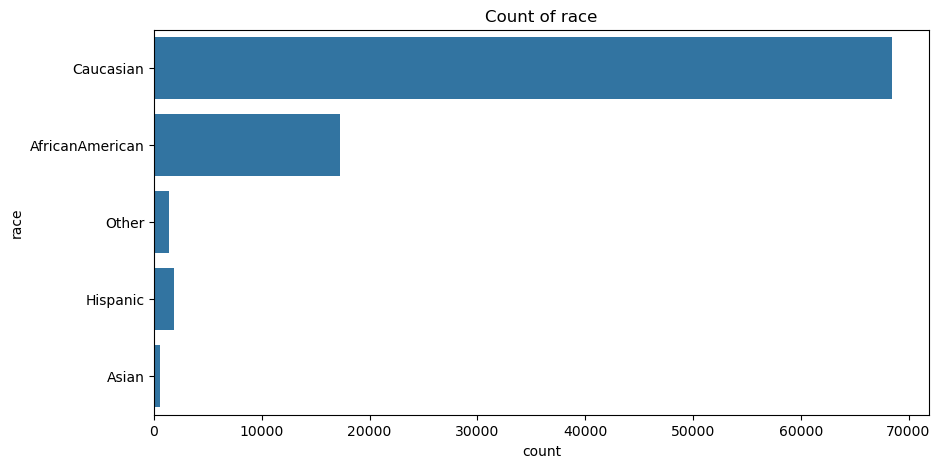

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(y = train_data['race']).set_title('Count of race')

In [39]:
data['race'].fillna(data['race'].mode()[0], inplace=True)

### Gender

The gender column tells us whether the patient is male or female

In [17]:
# female is 0 , male is 1
train_data['gender'].value_counts()

gender
0.0    48462
1.0    41643
Name: count, dtype: int64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'Count of gender')

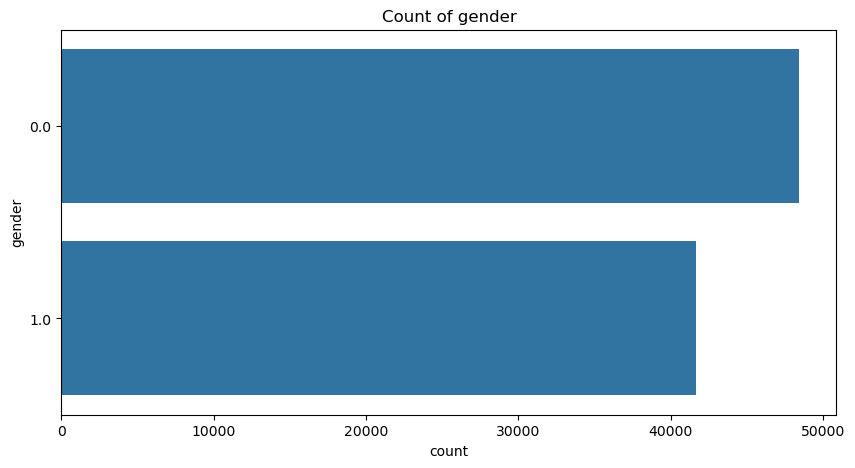

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(y=train_data['gender']).set_title('Count of gender')

### Age


In [40]:
train_data['age'].value_counts()

age
[70-80)     23452
[60-70)     20204
[50-60)     15529
[80-90)     15466
[40-50)      8770
[30-40)      3399
[90-100)     2529
[20-30)      1470
[10-20)       625
[0-10)        145
Name: count, dtype: int64

Text(0.5, 1.0, 'Count of age')

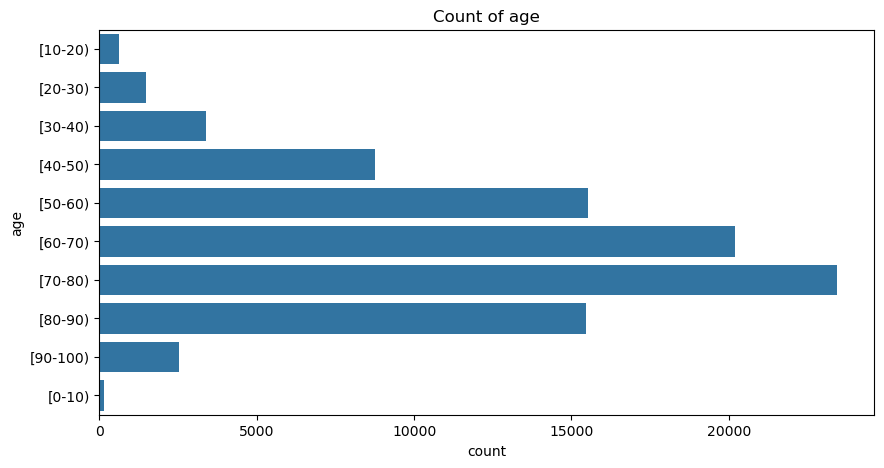

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(y = train_data['age']).set_title('Count of age')

### Admission_type_id

Obtained from mappings given in uiuc:

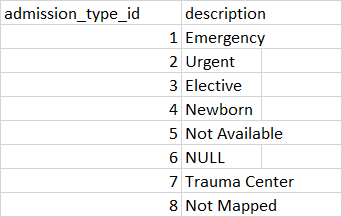

In [42]:
train_data['admission_type_id'].value_counts()

admission_type_id
1    48612
3    16912
2    16691
6     4762
5     4300
8      284
7       18
4       10
Name: count, dtype: int64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'Count of admission type')

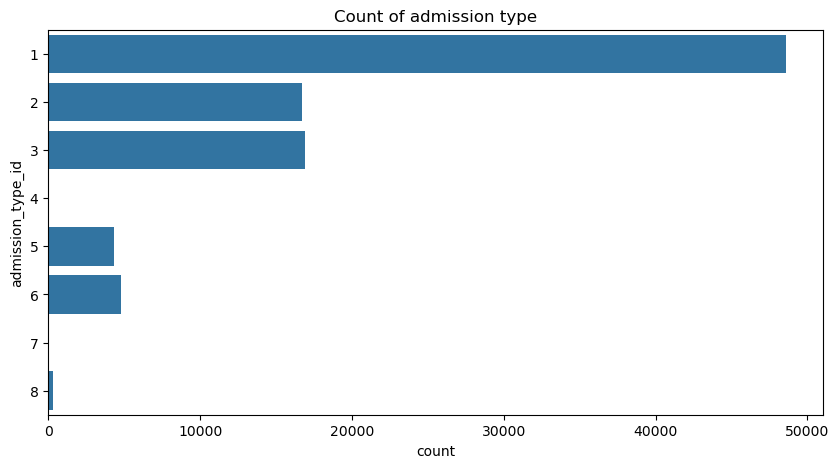

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(y = train_data['admission_type_id']).set_title('Count of admission type')

### Discharge_dispostion_id

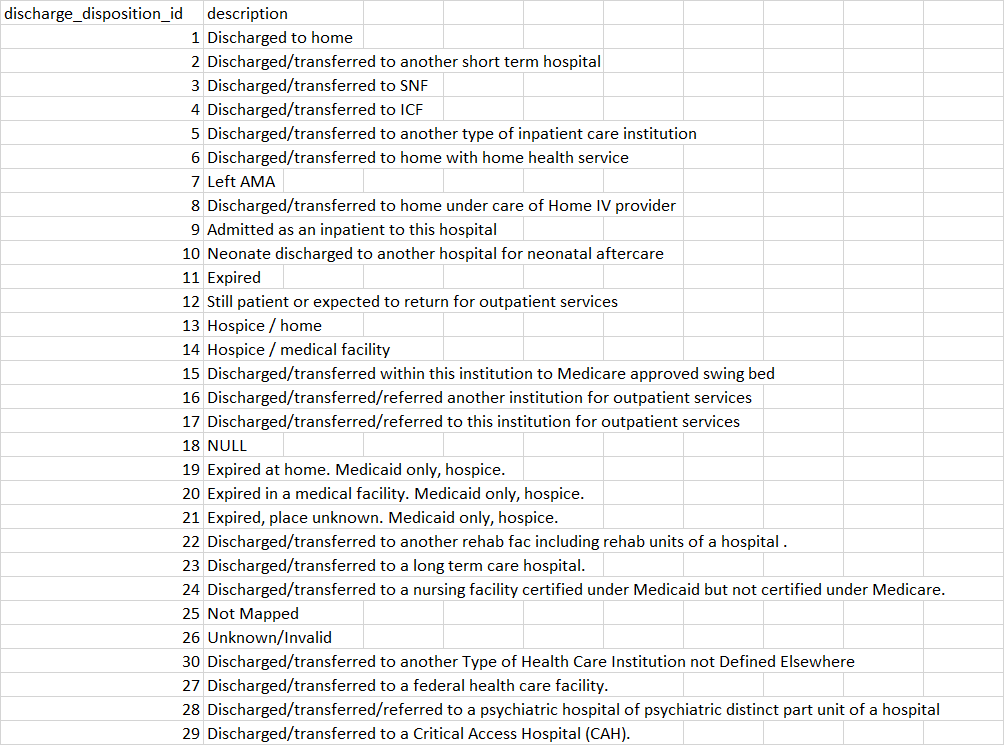

In [44]:
train_data['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     54187
3     12607
6     11589
18     3341
2      1893
22     1791
11     1475
5      1071
25      882
4       738
7       557
23      380
13      346
14      341
28      130
8        98
15       59
24       42
9        19
17       12
16        9
19        7
10        6
27        4
12        3
20        2
Name: count, dtype: int64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


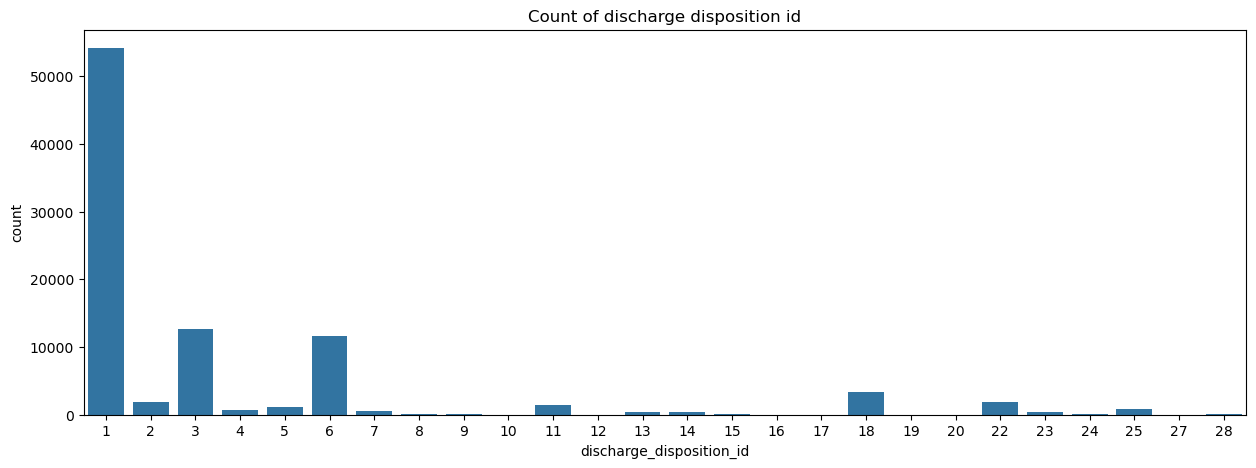

In [46]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['discharge_disposition_id']).set_title('Count of discharge disposition id');

### Adimission_source_id

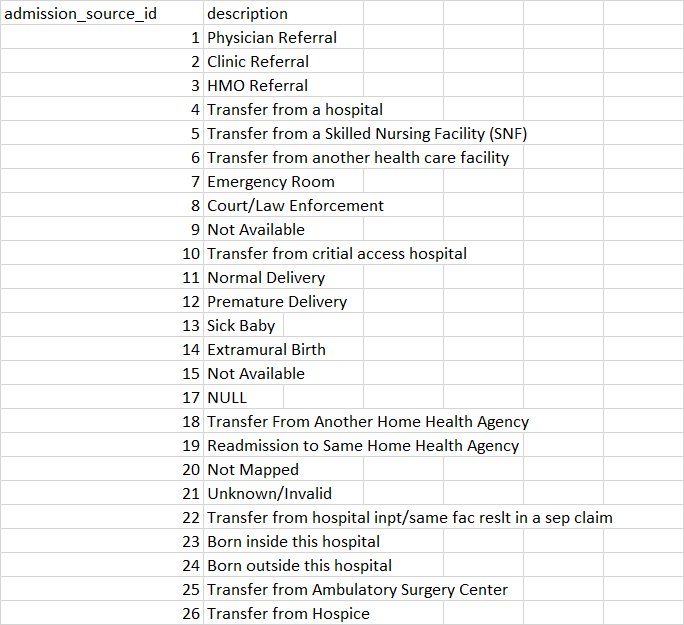

In [47]:
train_data['admission_source_id'].value_counts()

admission_source_id
7     51839
1     26563
17     6099
4      2837
6      2035
2       982
5       759
3       172
20      147
9       115
8        15
22       12
10        8
14        2
25        2
11        1
13        1
Name: count, dtype: int64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'Count of admission source id')

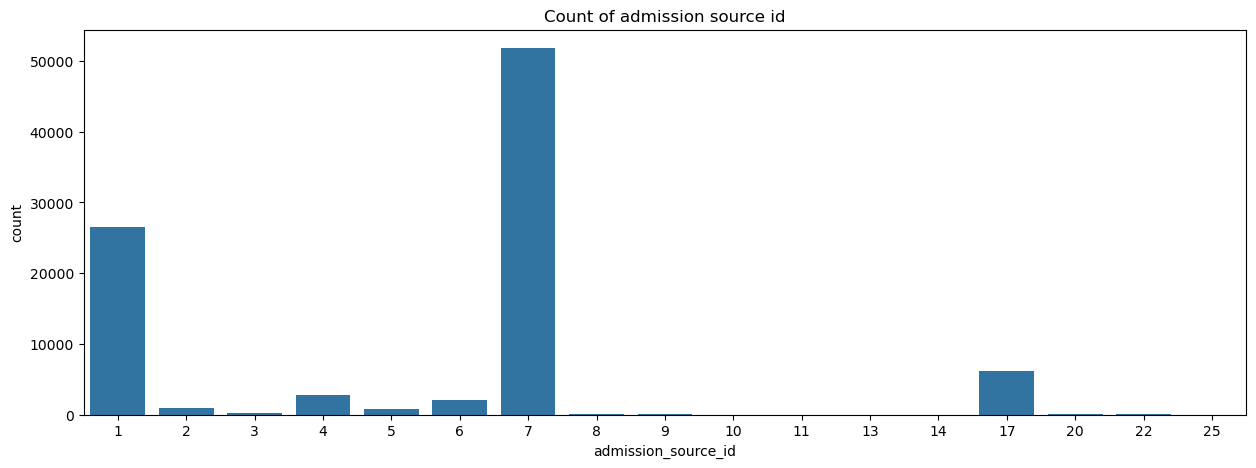

In [48]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['admission_source_id']).set_title('Count of admission source id')

### Time_in_hospital

In [49]:
train_data['time_in_hospital'].value_counts()

time_in_hospital
3     16059
2     15496
1     12798
4     12494
5      8967
6      6722
7      5282
8      3926
9      2704
10     2105
11     1687
12     1318
13     1101
14      930
Name: count, dtype: int64

In [50]:
train_data['time_in_hospital'].describe()

count    91589.000000
mean         4.395550
std          2.987944
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         14.000000
Name: time_in_hospital, dtype: float64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'Count of time in hospital')

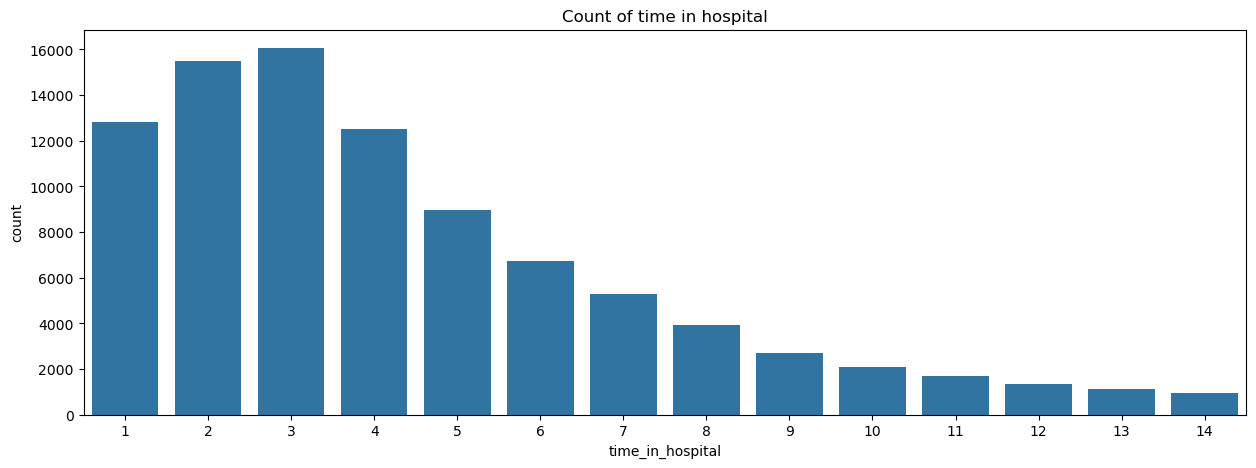

In [51]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['time_in_hospital']).set_title('Count of time in hospital')

### Payer_code

In [52]:
train_data['payer_code'].value_counts()

payer_code
MC    29160
HM     5658
SP     4522
BC     4167
MD     3193
CP     2281
UN     2209
CM     1737
OG      930
PO      530
DM      490
CH      132
WC      126
OT       83
MP       70
SI       53
FR        1
Name: count, dtype: int64

### Medical_specialty

In [54]:
train_data['medical_specialty'].describe()

count                46597
unique                  72
top       InternalMedicine
freq                 13191
Name: medical_specialty, dtype: object

### num_lab_procedures

In [ ]:
train_data['num_lab_procedures'].describe()

count    90105.000000
mean        42.928450
std         19.625543
min          1.000000
25%         31.000000
50%         44.000000
75%         57.000000
max        132.000000
Name: num_lab_procedures, dtype: float64

Text(0.5, 1.0, 'number of lab procedures')

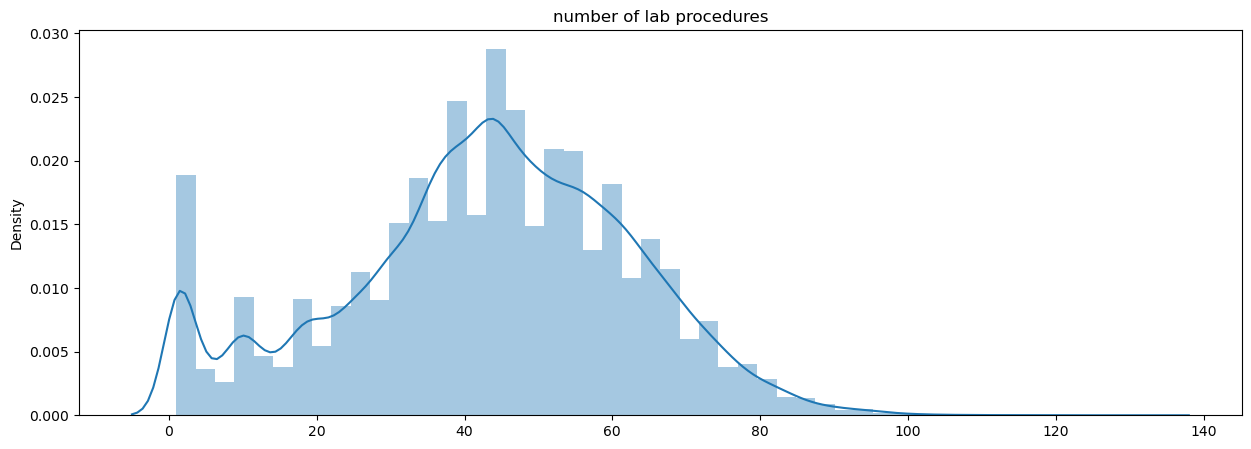

In [ ]:
plt.figure(figsize=(15,5))
sns.distplot(x = train_data['num_lab_procedures']).set_title('number of lab procedures')

### Num_procedures

In [56]:
train_data['num_procedures'].value_counts()

num_procedures
0    42010
1    18713
2    11414
3     8474
6     4444
4     3765
5     2769
Name: count, dtype: int64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'number of other procedures')

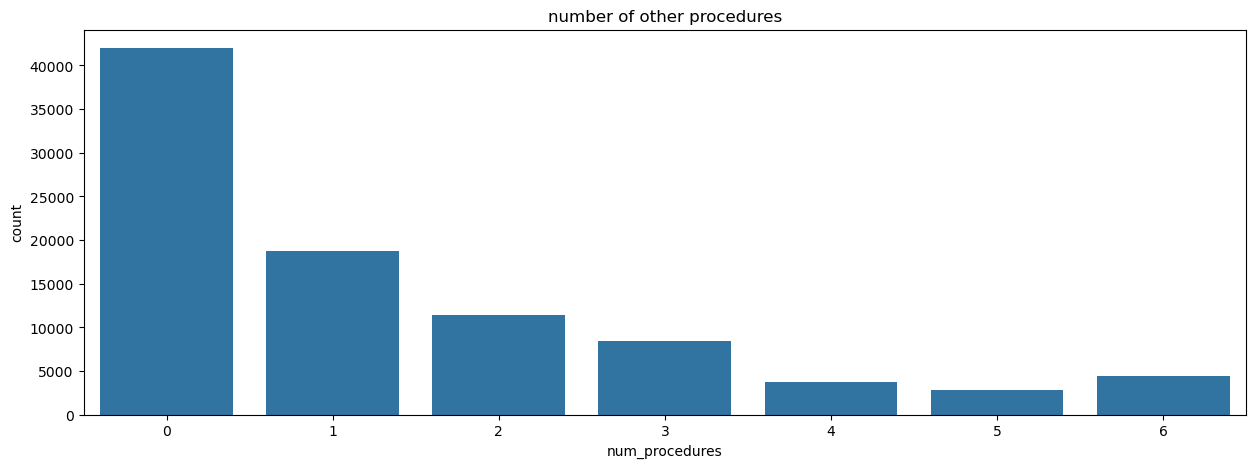

In [57]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['num_procedures']).set_title('number of other procedures')

### Num_medications

In [58]:
train_data['num_medications'].describe()

count    91589.000000
mean        16.018135
std          8.122843
min          1.000000
25%         10.000000
50%         15.000000
75%         20.000000
max         81.000000
Name: num_medications, dtype: float64

Text(0.5, 1.0, 'number of medications')

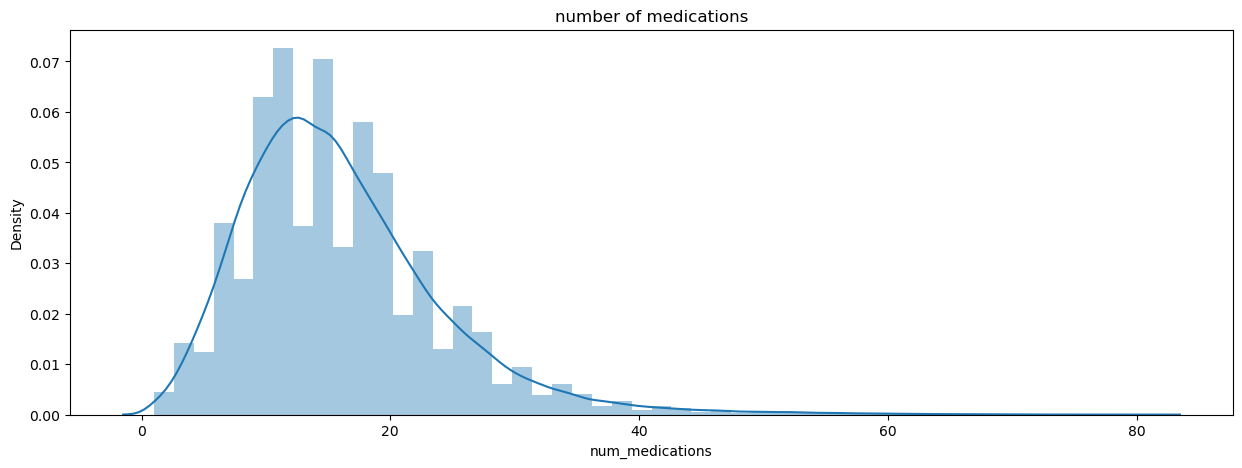

In [59]:
plt.figure(figsize=(15,5))
sns.distplot(train_data['num_medications']).set_title('number of medications')

### Number_outpatient

In [60]:
train_data['number_outpatient'].describe()

count    91589.000000
mean         0.368811
std          1.272073
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         42.000000
Name: number_outpatient, dtype: float64

In [61]:
train_data['number_outpatient'].value_counts()

number_outpatient
0     76543
1      7695
2      3239
3      1829
4       975
5       480
6       273
7       140
8        84
9        71
10       49
11       37
13       29
12       28
14       27
15       19
16       14
20        7
21        7
17        7
22        5
19        3
18        3
27        3
24        3
29        2
35        2
33        2
25        2
26        2
42        1
34        1
36        1
39        1
28        1
23        1
37        1
38        1
40        1
Name: count, dtype: int64

Text(0.5, 1.0, 'number of outpatient visits')

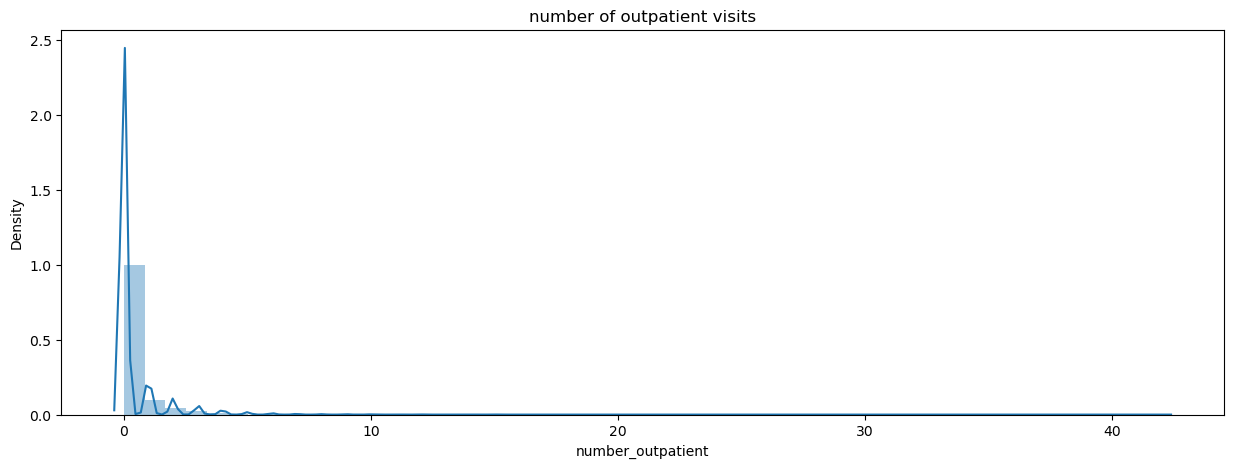

In [62]:
plt.figure(figsize=(15,5))
sns.distplot(train_data['number_outpatient']).set_title('number of outpatient visits')

### Number_emergency

In [63]:
train_data['number_emergency'].describe()

count    91589.000000
mean         0.198747
std          0.945813
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         76.000000
Name: number_emergency, dtype: float64

Text(0.5, 1.0, 'number of emergency visits')

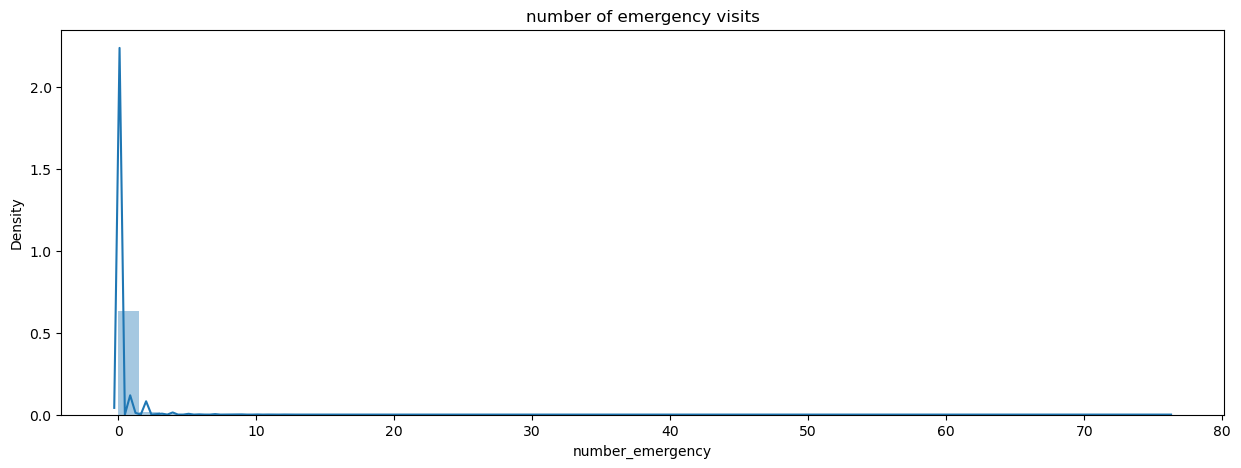

In [64]:
plt.figure(figsize=(15,5))
sns.distplot(train_data['number_emergency']).set_title('number of emergency visits')

### Number_inpatient

In [65]:
train_data['number_inpatient'].describe()

count    91589.000000
mean         0.634716
std          1.263945
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         21.000000
Name: number_inpatient, dtype: float64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0.5, 1.0, 'number of inpatient visits')

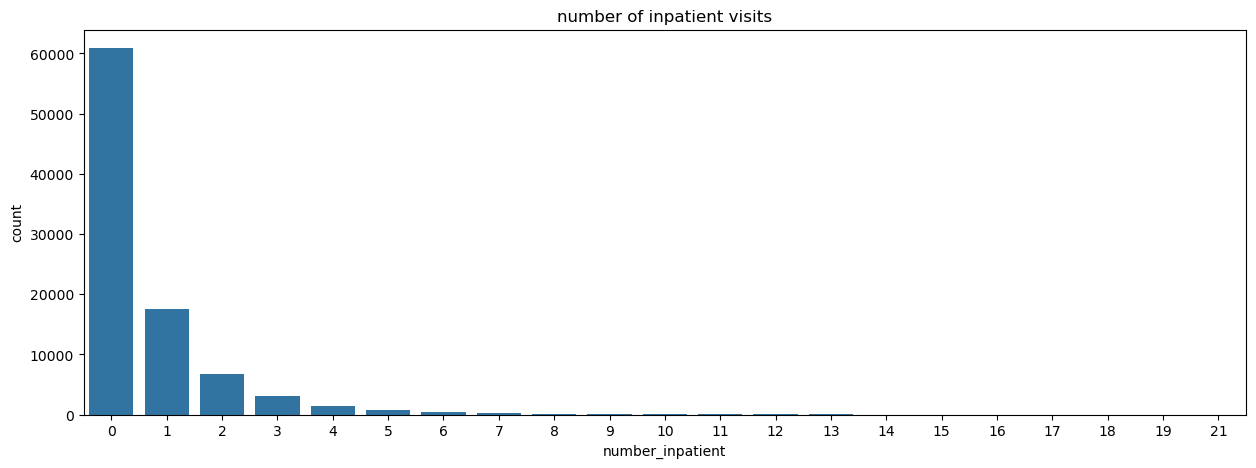

In [66]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['number_inpatient']).set_title('number of inpatient visits')

### Diagnosis

All three columns contain code which are categorized into one of the 9 groups given below.

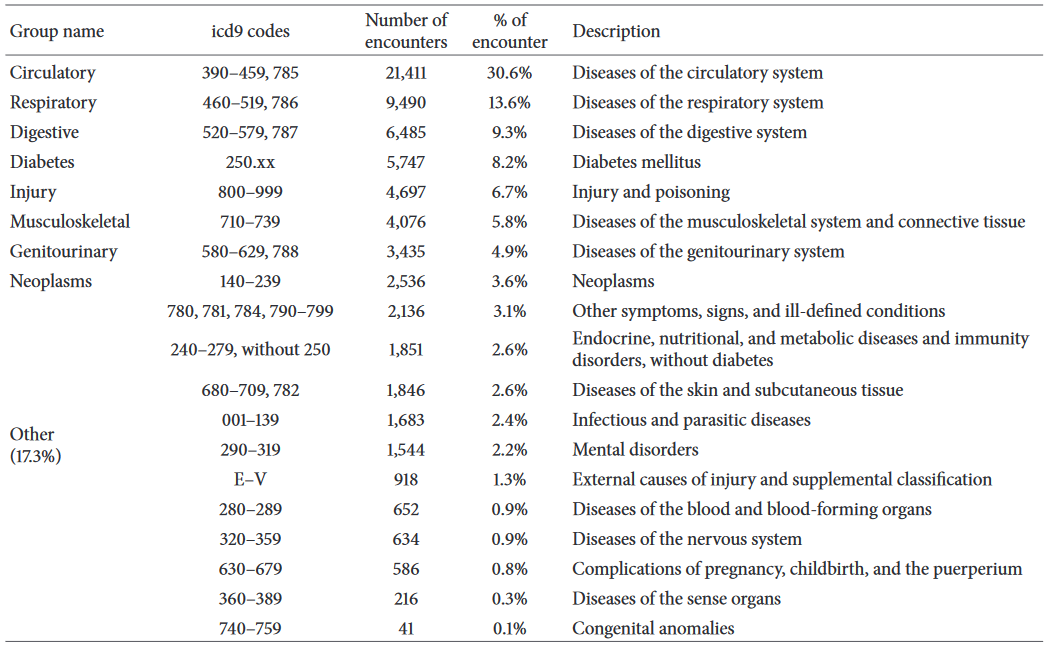

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


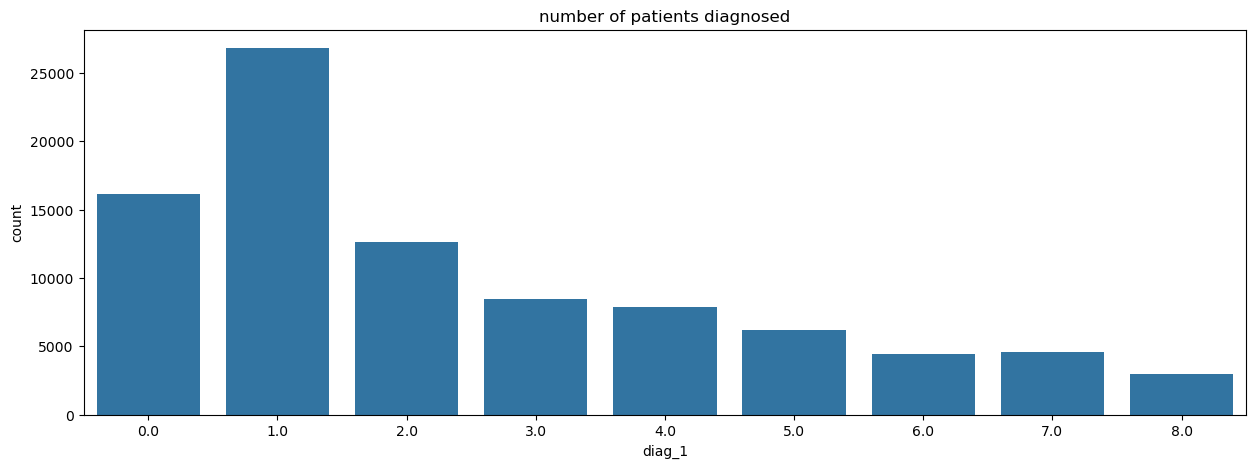

In [ ]:
plt.figure(figsize=(15, 5))
sns.countplot(x = train_data['diag_1']).set_title('number of patients diagnosed');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


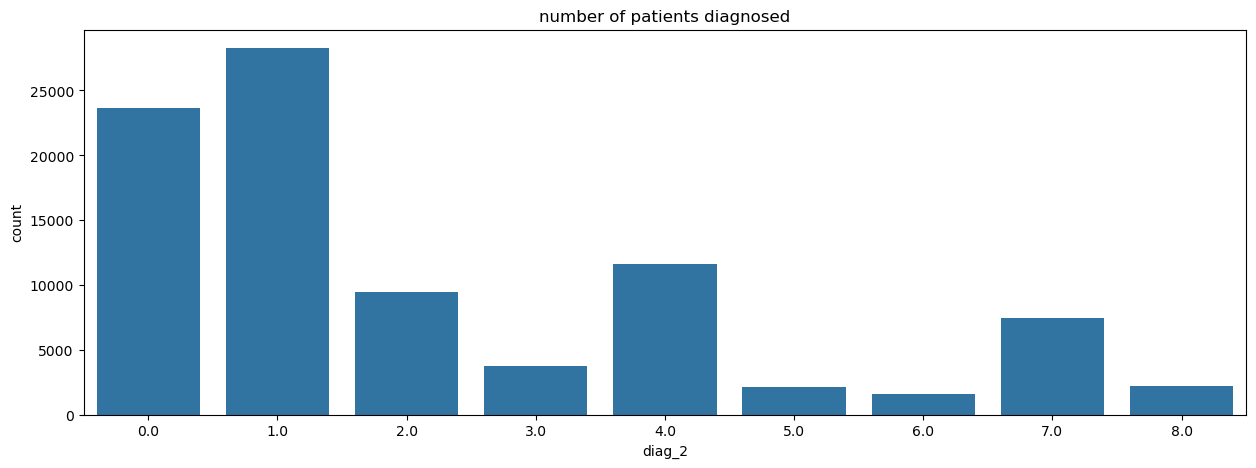

In [ ]:
plt.figure(figsize=(15, 5))
sns.countplot(x = train_data['diag_2']).set_title('number of patients diagnosed');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


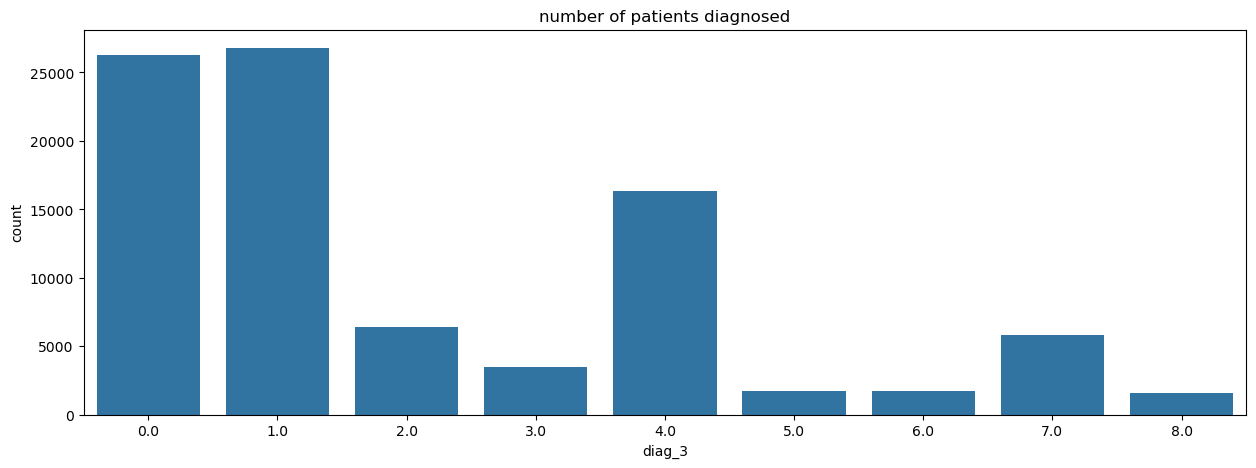

In [ ]:
plt.figure(figsize=(15, 5))
sns.countplot(x = train_data['diag_3']).set_title('number of patients diagnosed');

### Number_diagnoses

In [ ]:
train_data['number_diagnoses'].value_counts()

number_diagnoses
9     43519
5     10194
8      9337
7      9319
6      9012
4      4972
3      2542
2       914
1       194
16       38
10       15
13       14
11       11
15        9
12        8
14        7
Name: count, dtype: int64

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


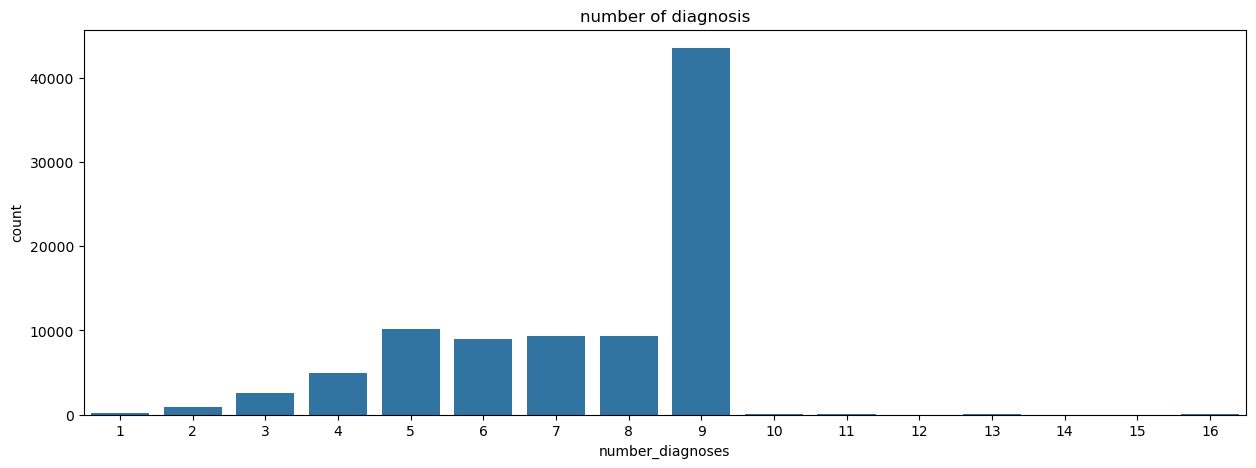

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['number_diagnoses']).set_title('number of diagnosis');

### Medications

In [67]:
cols = ['metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone']

In [68]:
medications = train_data[cols]

metformin
No        73515
Steady    16593
Up          965
Down        516
Name: count, dtype: int64
repaglinide
No        90196
Steady     1254
Up           98
Down         41
Name: count, dtype: int64
nateglinide
No        90960
Steady      598
Up           21
Down         10
Name: count, dtype: int64
chlorpropamide
No        91516
Steady       68
Up            5
Name: count, dtype: int64
glimepiride
No        86914
Steady     4210
Up          295
Down        170
Name: count, dtype: int64
acetohexamide
No        91588
Steady        1
Name: count, dtype: int64
glipizide
No        80162
Steady    10220
Up          702
Down        505
Name: count, dtype: int64
glyburide
No        81977
Steady     8368
Up          736
Down        508
Name: count, dtype: int64
tolbutamide
No        91569
Steady       20
Name: count, dtype: int64
pioglitazone
No        84979
Steady     6284
Up          218
Down        108
Name: count, dtype: int64
rosiglitazone
No        85838
Steady     5505
Up          16

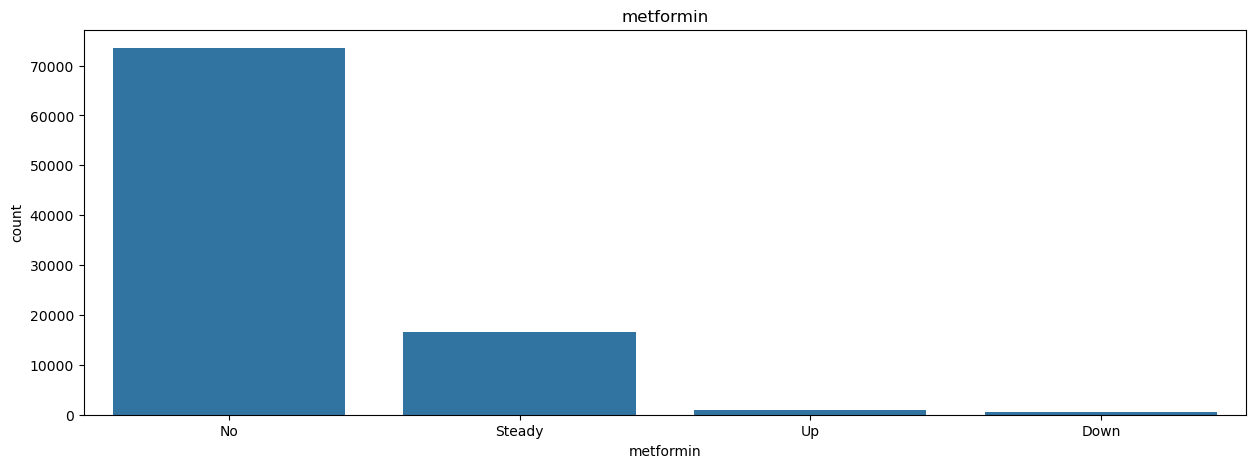

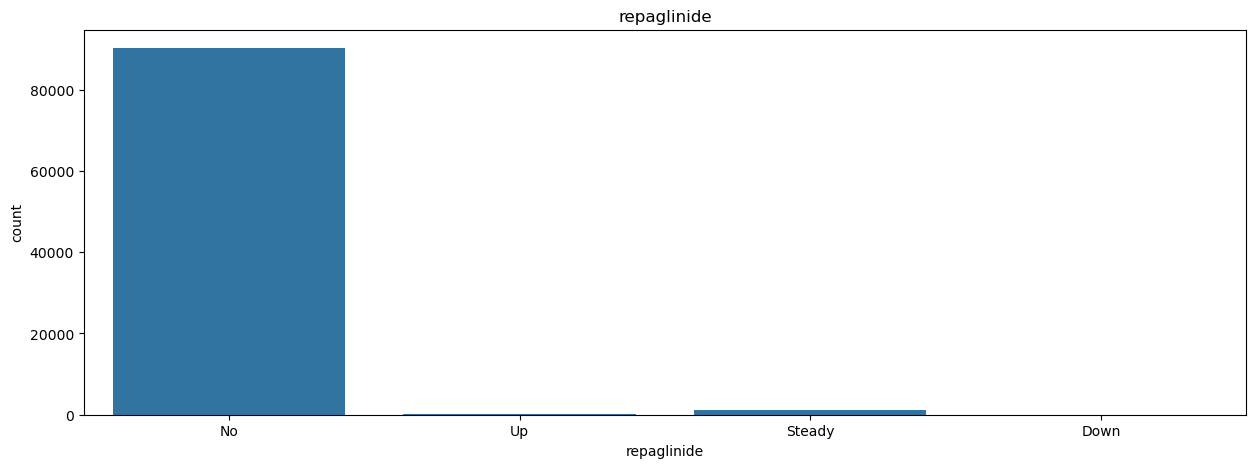

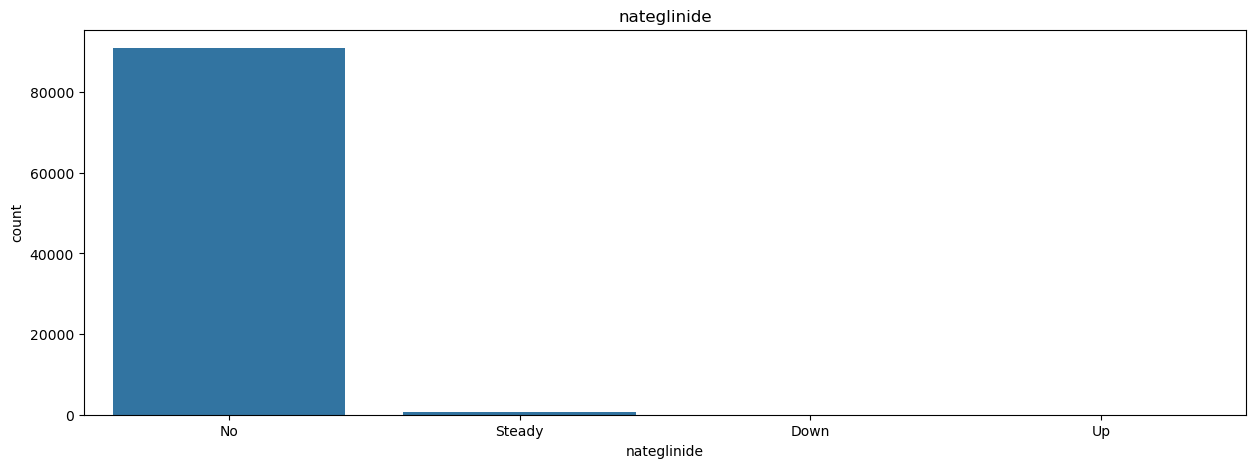

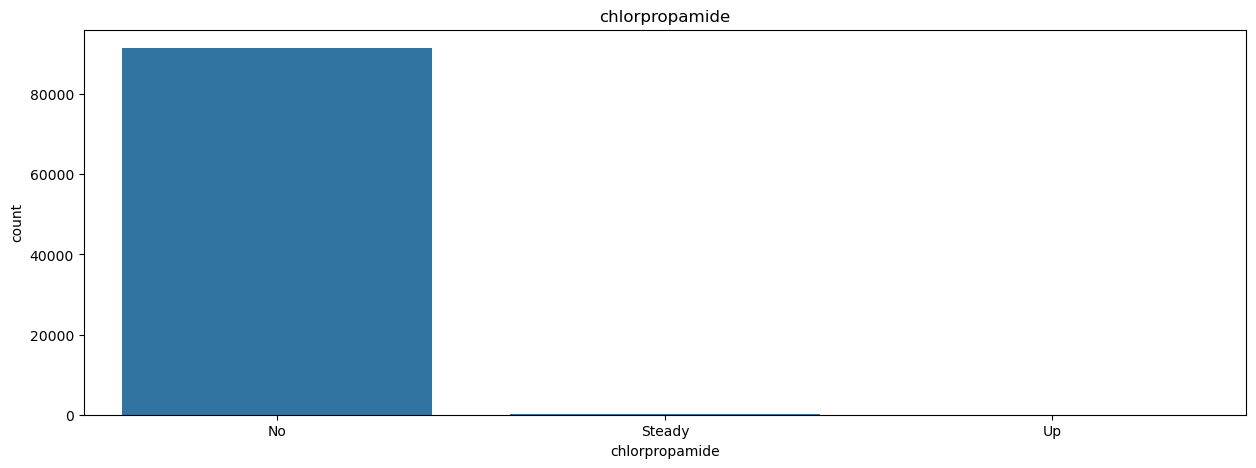

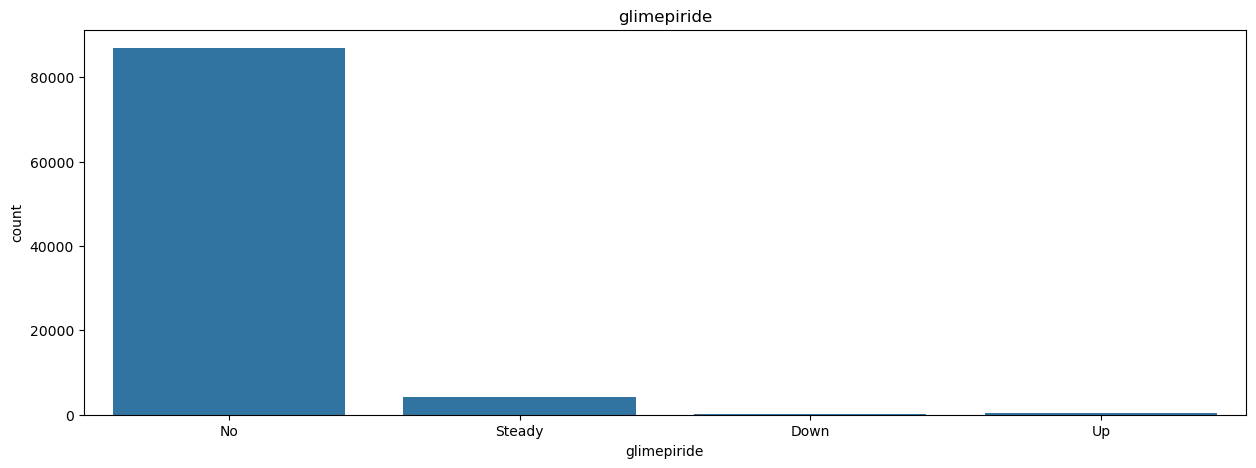

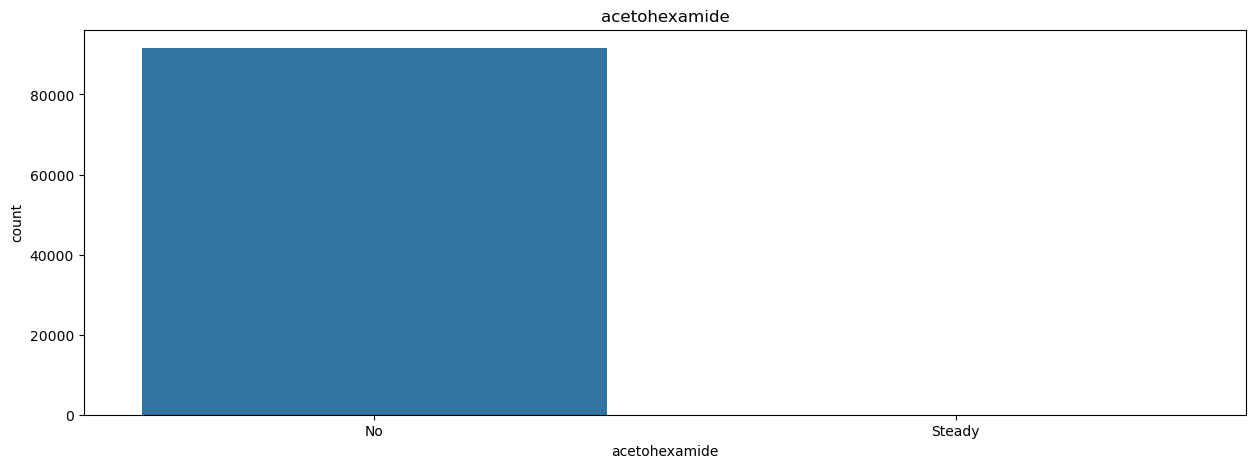

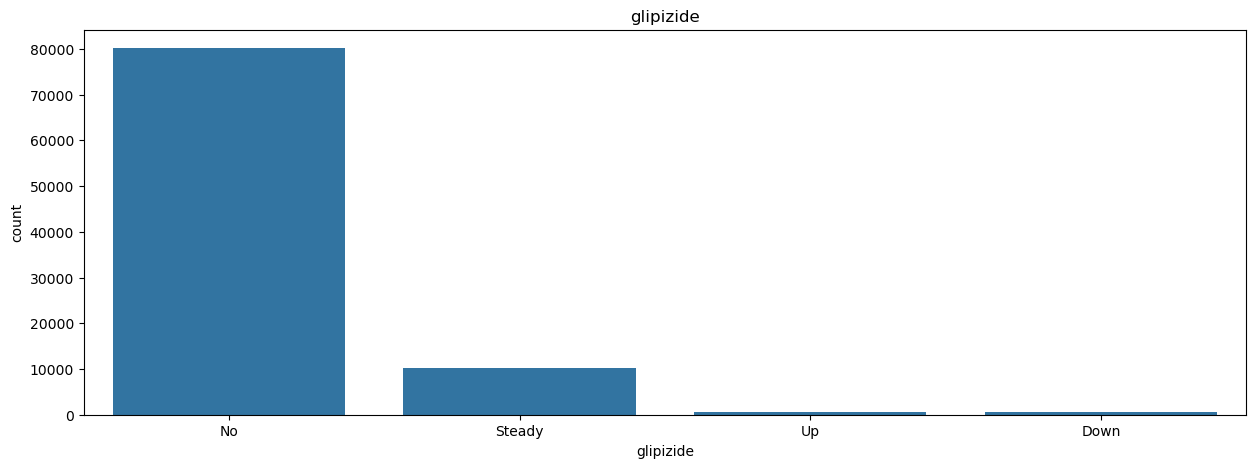

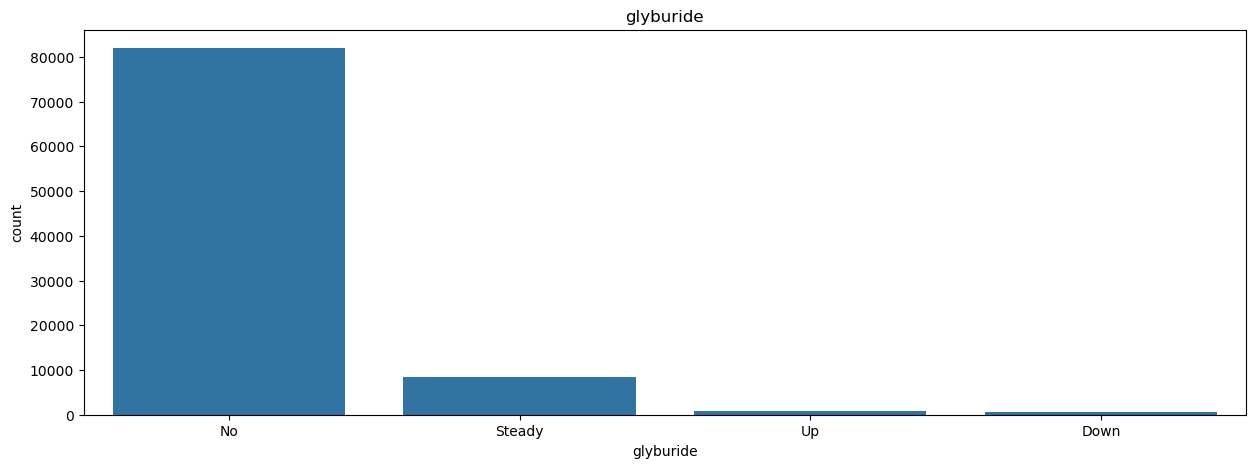

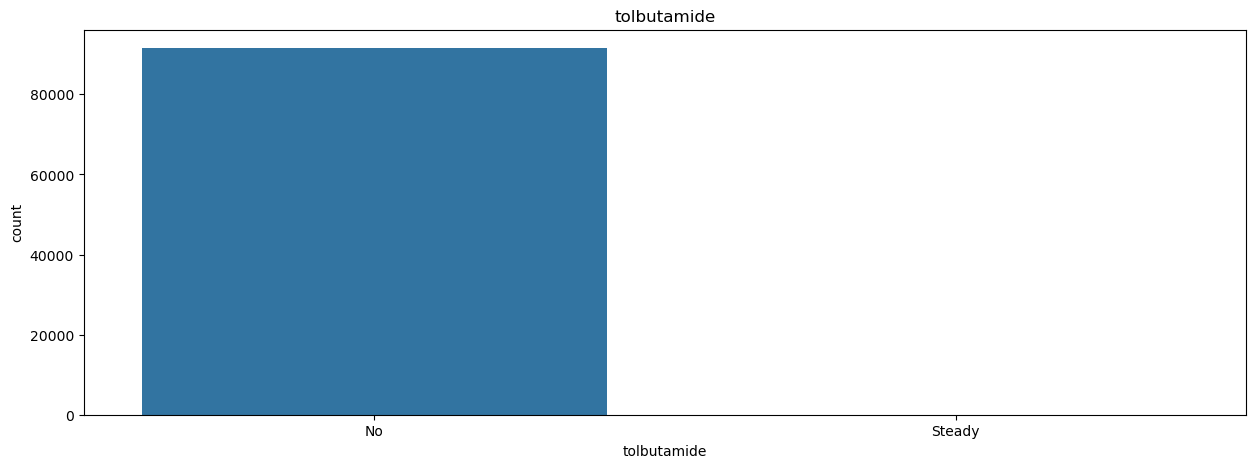

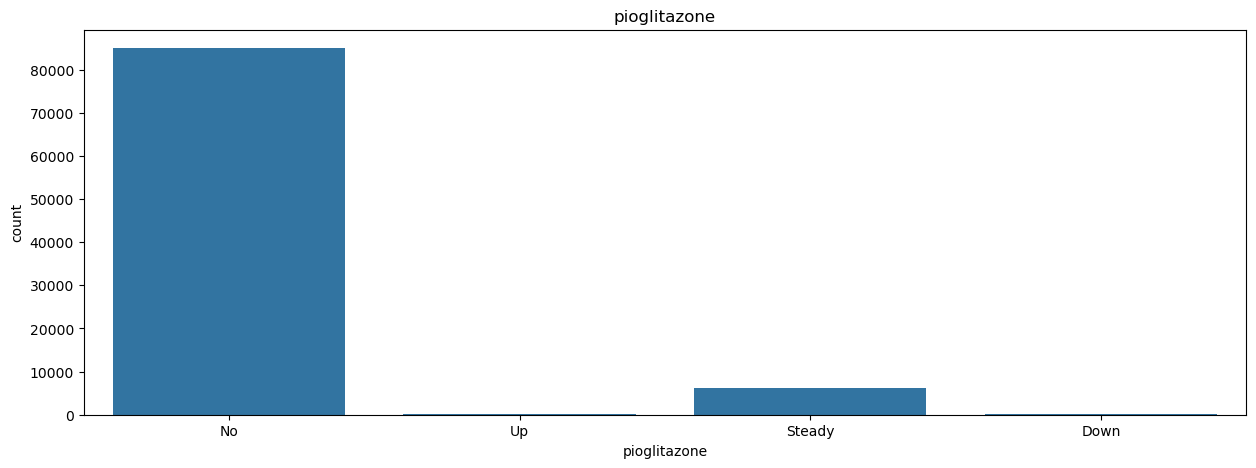

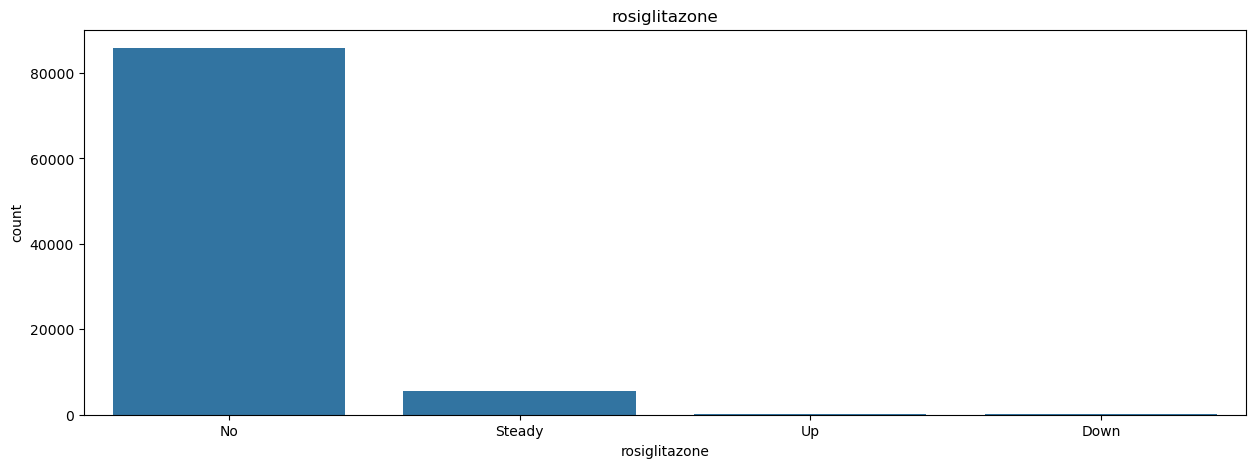

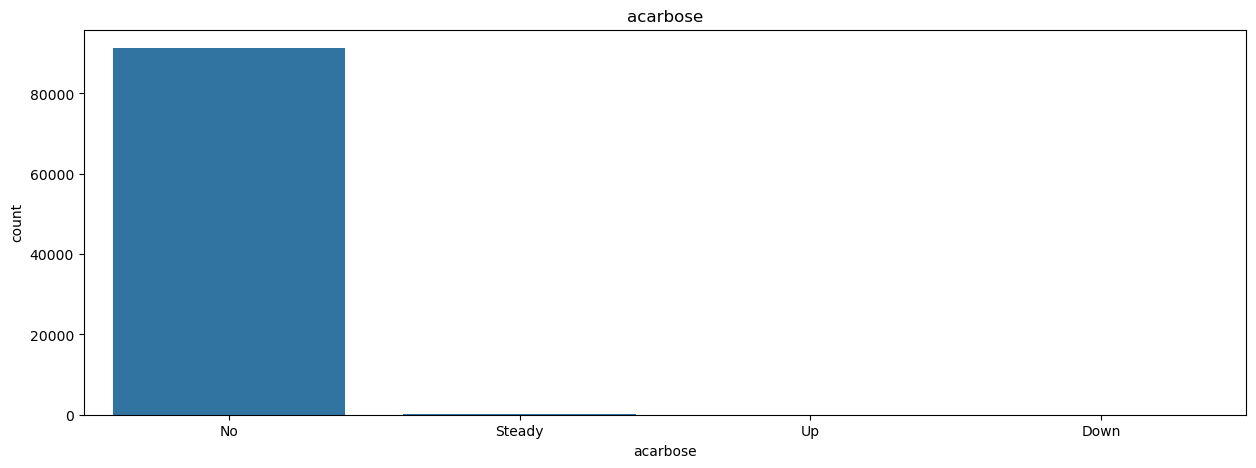

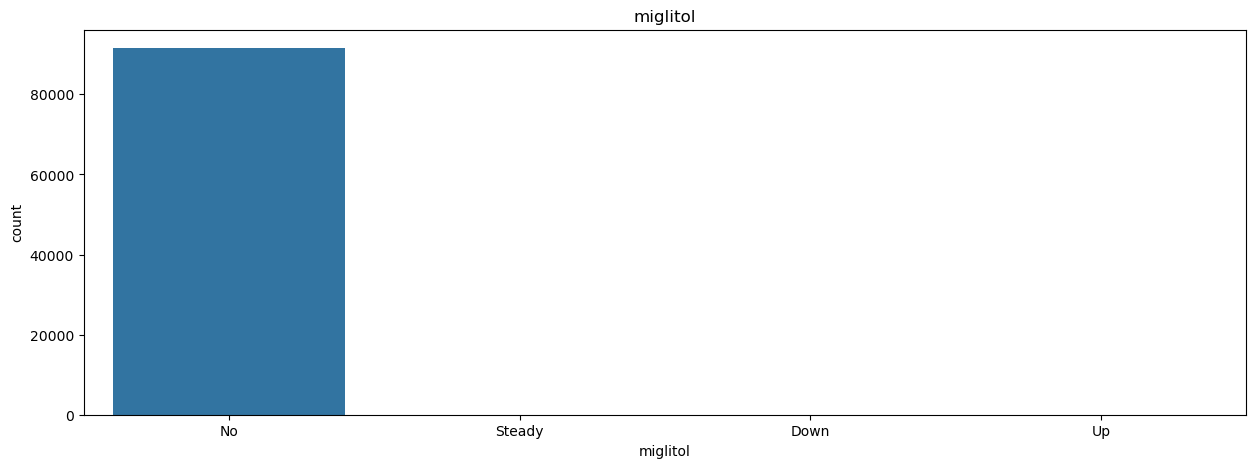

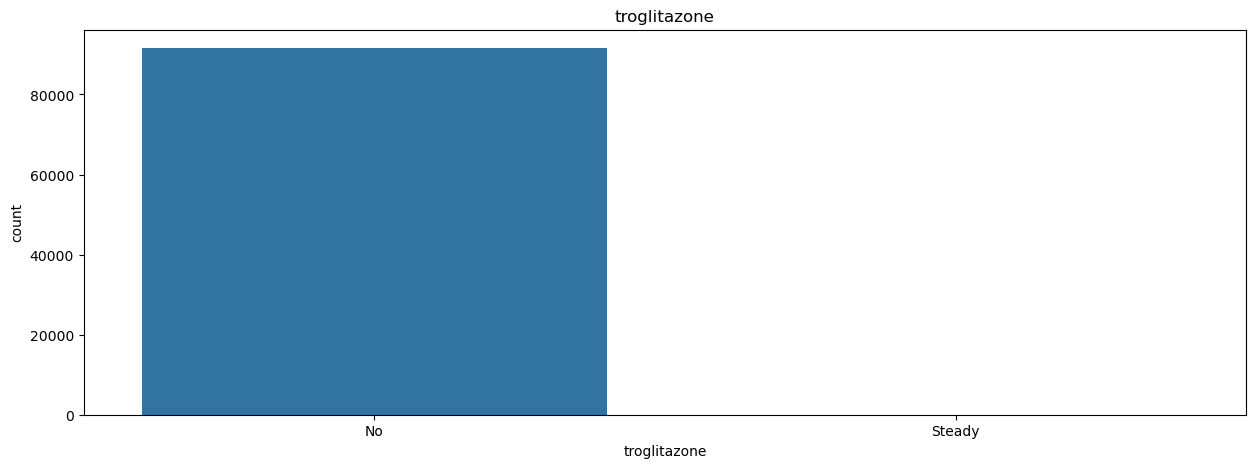

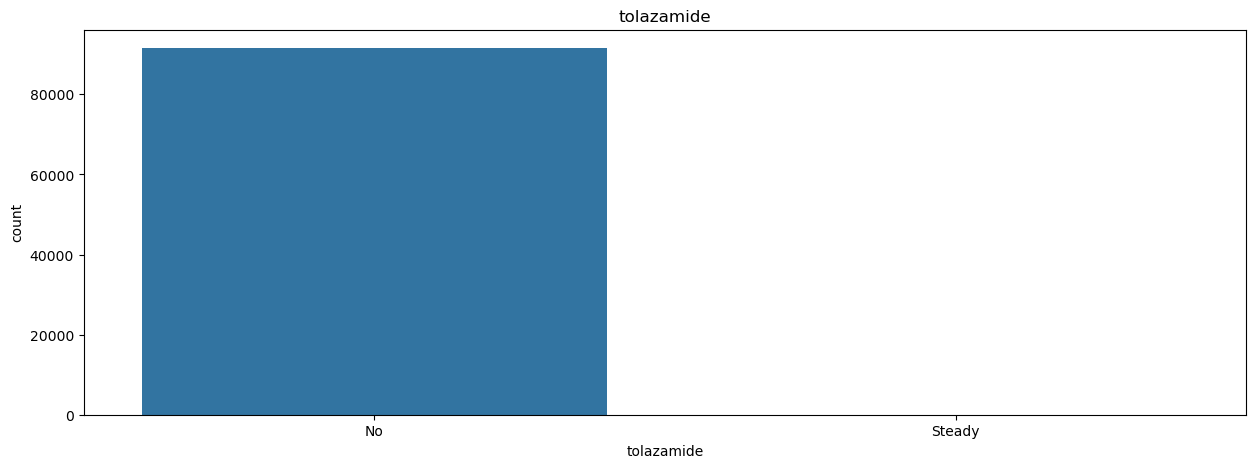

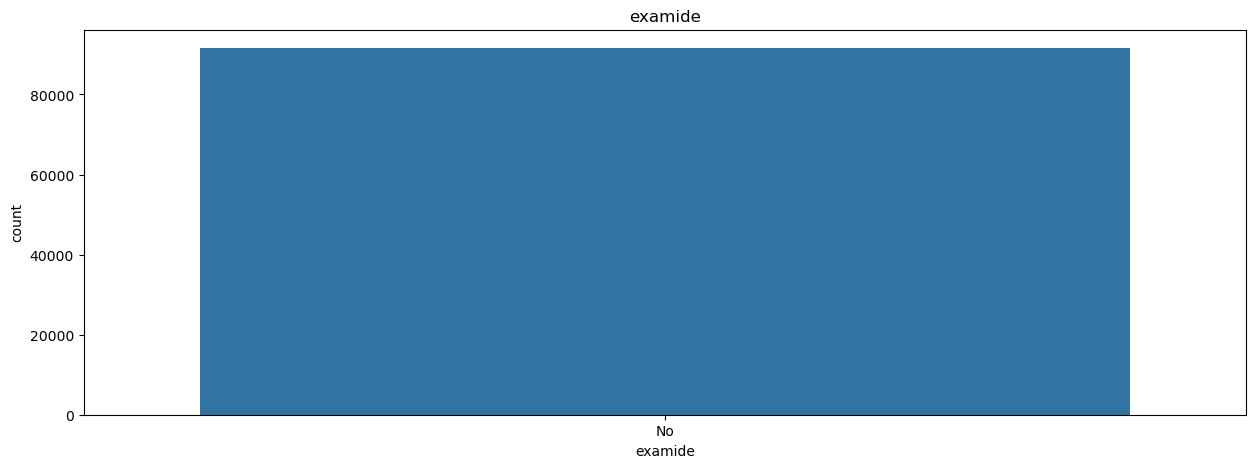

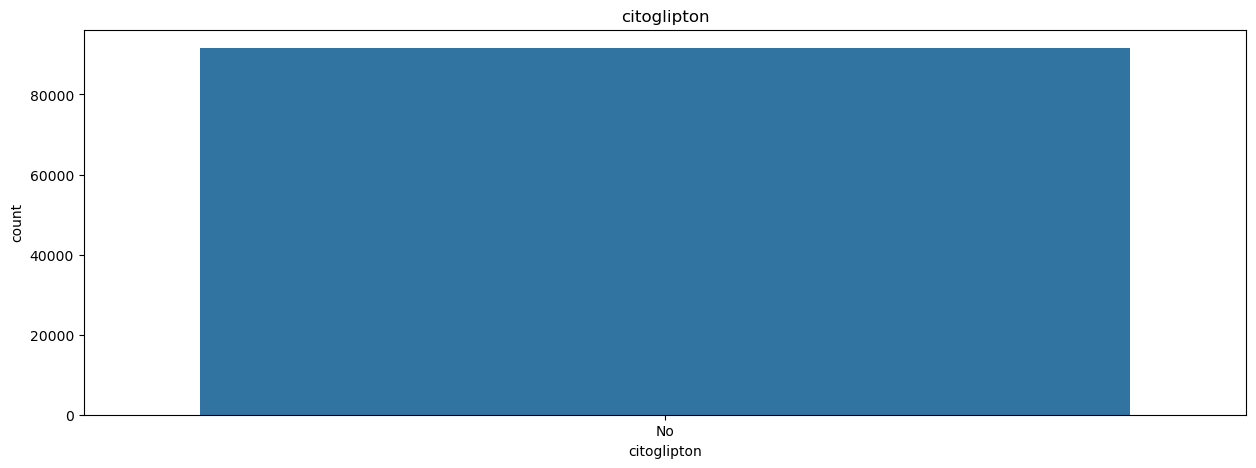

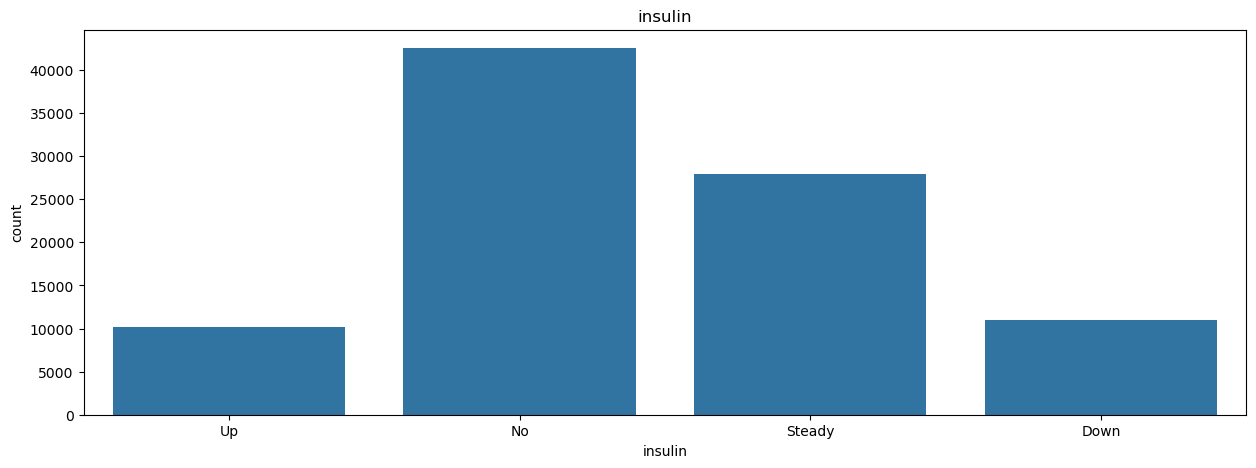

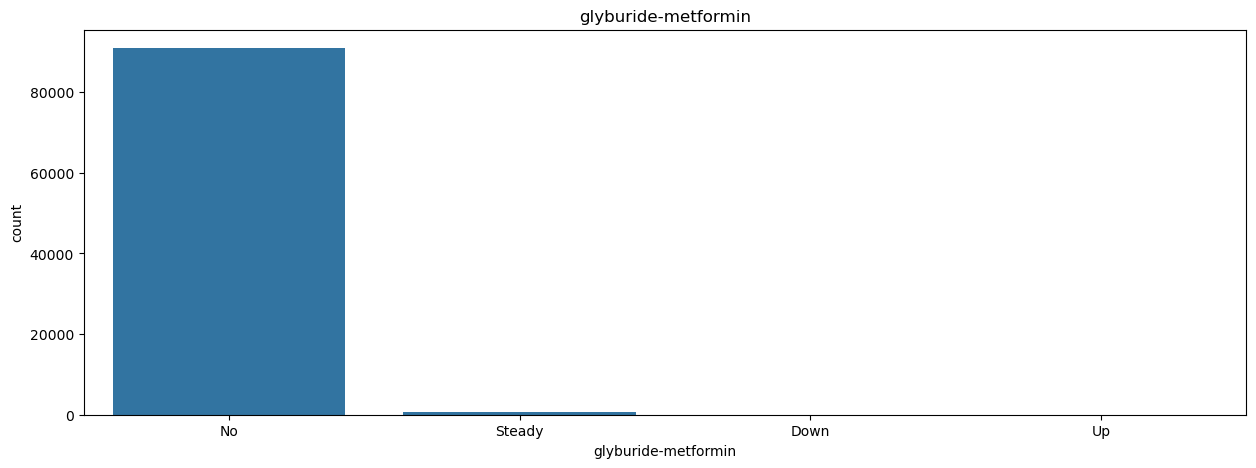

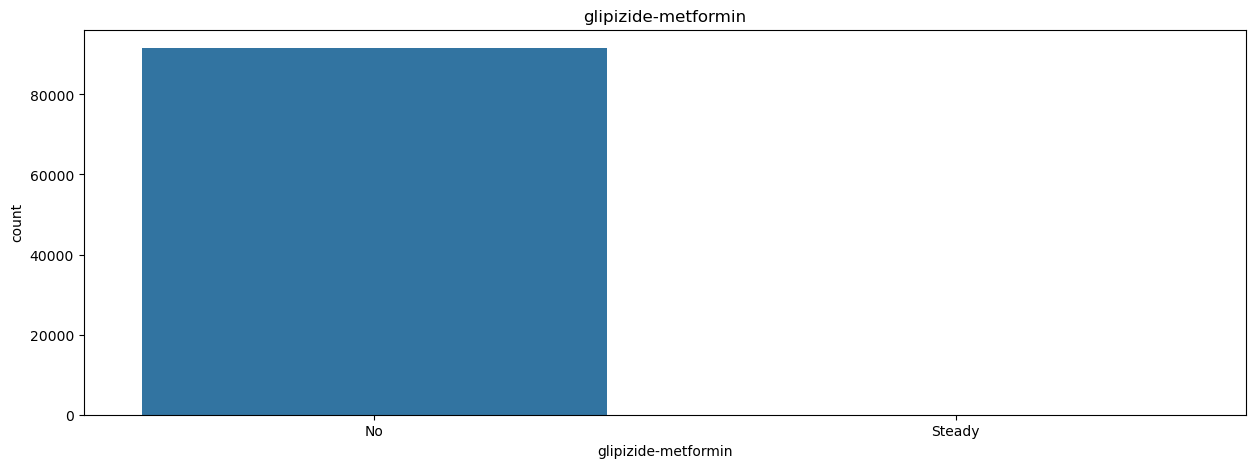

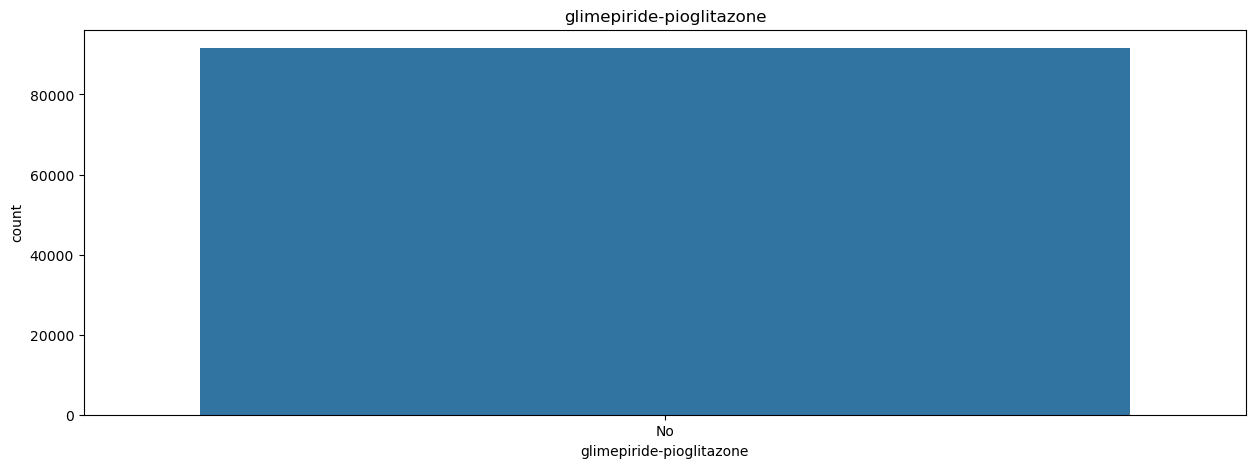

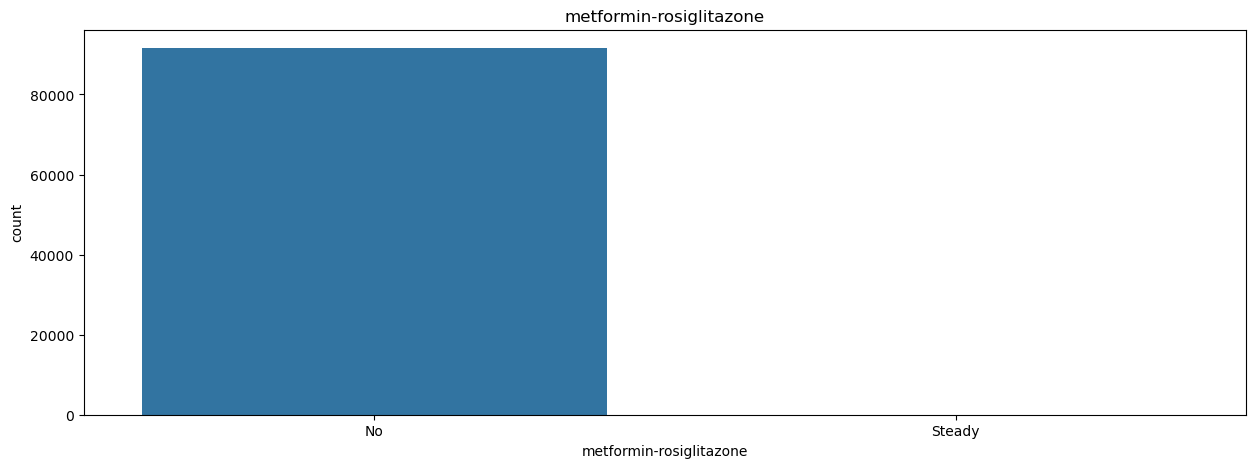

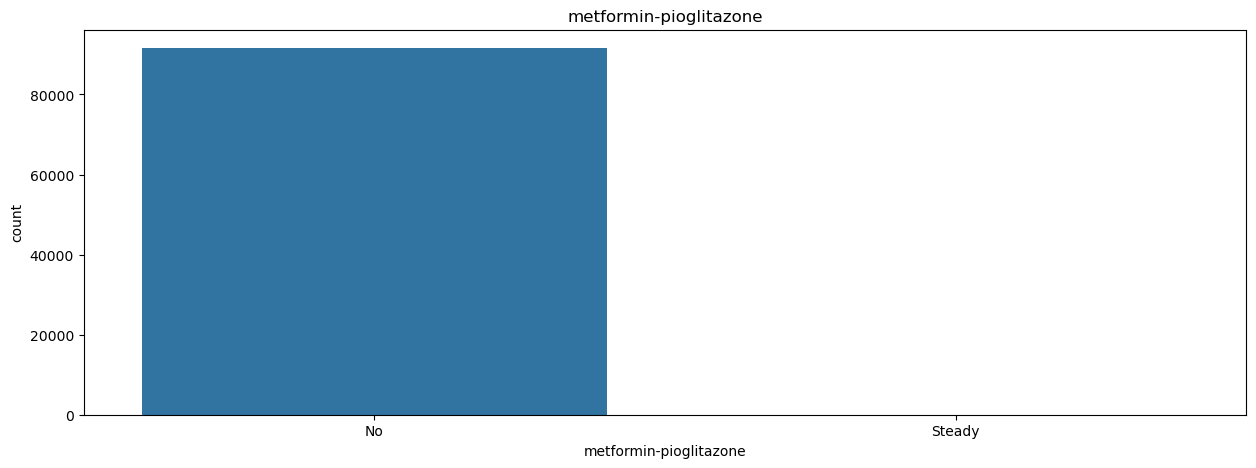

In [69]:
for i in cols:
  plt.figure(figsize=(15,5))
  print(medications[i].value_counts())
  sns.countplot(x = medications[i]).set_title(i);

### Change

In [70]:
train_data['change'].value_counts()

change
No    49235
Ch    42354
Name: count, dtype: int64

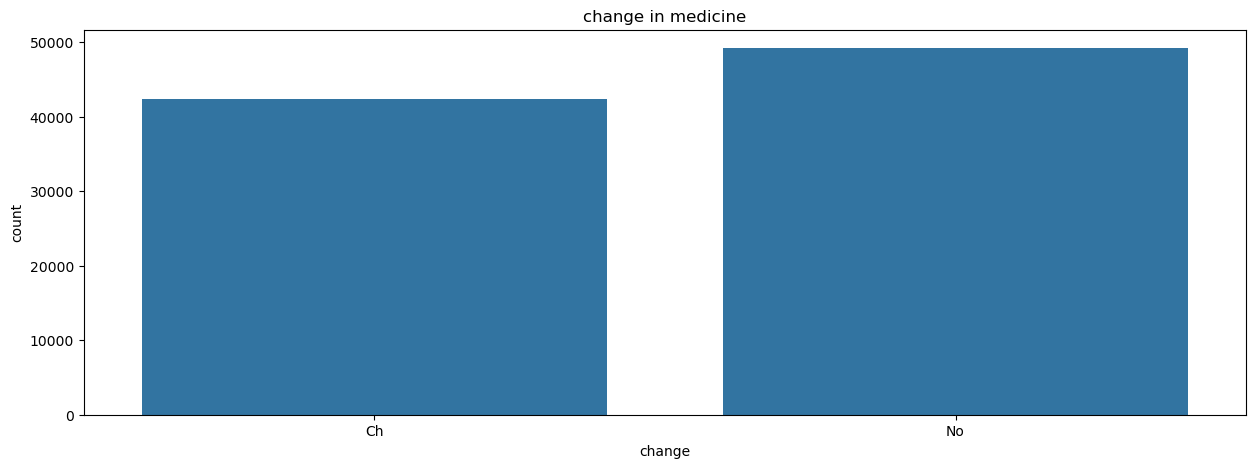

In [71]:
plt.figure(figsize=(15,5))
sns.countplot(x=train_data['change']).set_title('change in medicine');

### DiabetesMed

In [73]:
train_data['diabetesMed'].value_counts()

diabetesMed
Yes    70555
No     21034
Name: count, dtype: int64

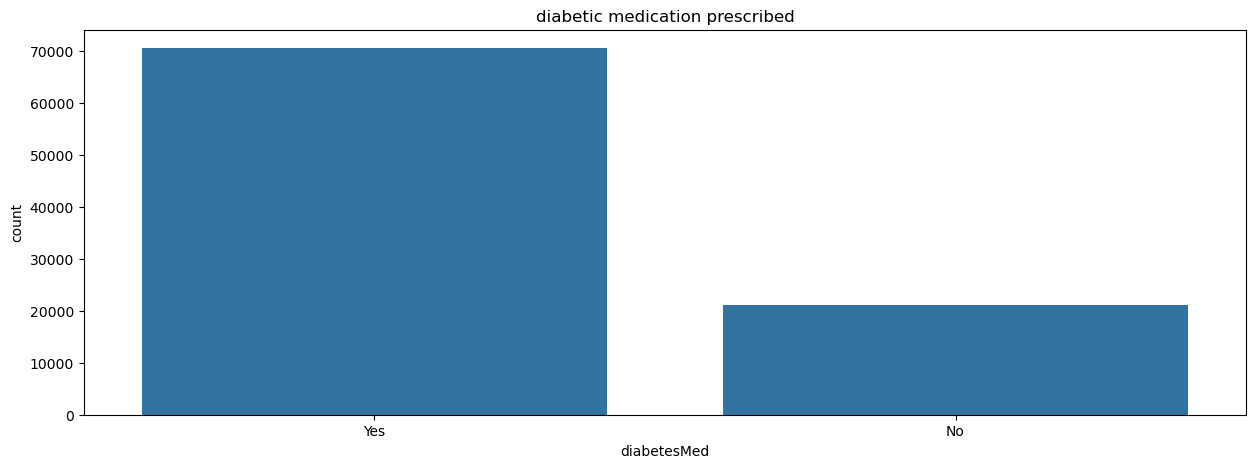

In [74]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['diabetesMed']).set_title('diabetic medication prescribed');

### Readmitted

In [75]:
train_data['readmitted'].value_counts()

readmitted
NO     49355
>30    31989
<30    10245
Name: count, dtype: int64

In [76]:
train_data.loc[train_data['readmitted'] == '<30', ['readmitted']] = 1
train_data.loc[train_data['readmitted'] == '>30', ['readmitted']] = 2
train_data.loc[train_data['readmitted'] == 'NO', ['readmitted']] = 0

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


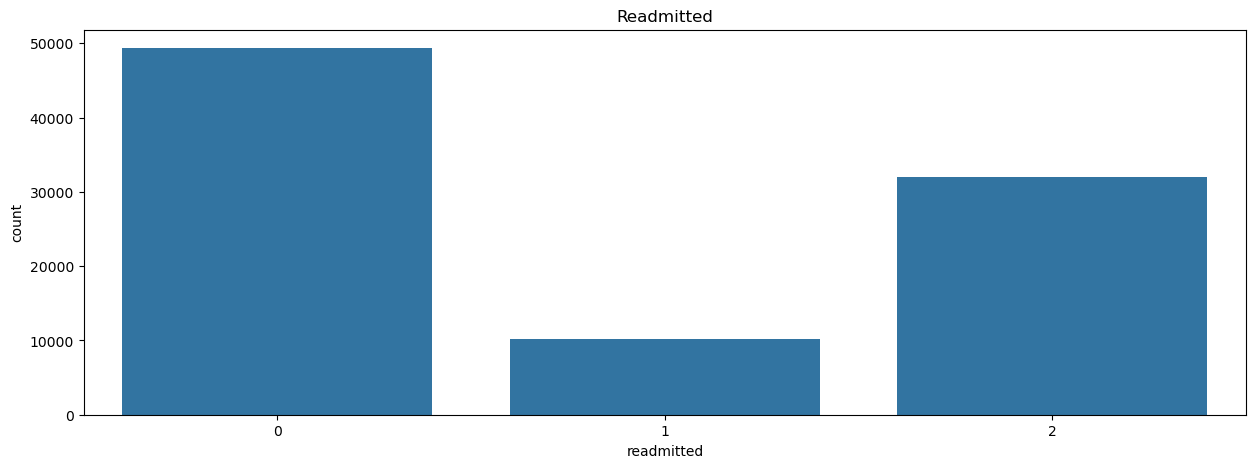

In [77]:
plt.figure(figsize=(15,5))
sns.countplot(x = train_data['readmitted']).set_title('Readmitted');

In [78]:
train_data['readmitted'].value_counts()/len(train_data)

readmitted
0    0.538875
2    0.349267
1    0.111858
Name: count, dtype: float64

## Brivariate and multivariate analysis

In [80]:
train_data = pd.read_csv('Dataset/processed/train_processed/network_train.csv')

In [81]:
train_data.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'metformin', 'glimepiride', 'glipizide',
       'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')

### Age VS readmitted,diagnosis &time in hospital

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


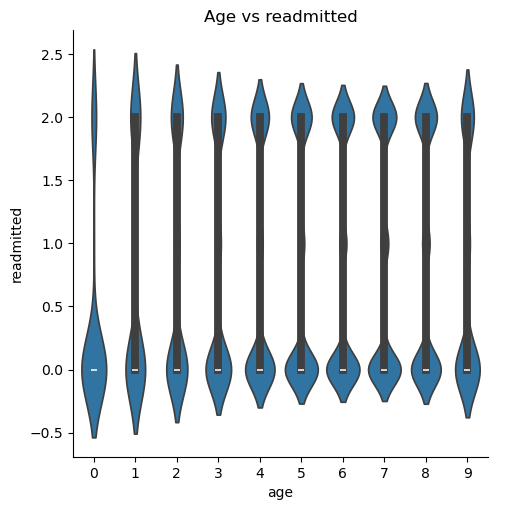

In [17]:
sns.catplot(x="age", y="readmitted",kind="violin", data=train_data);
plt.title('Age vs readmitted');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


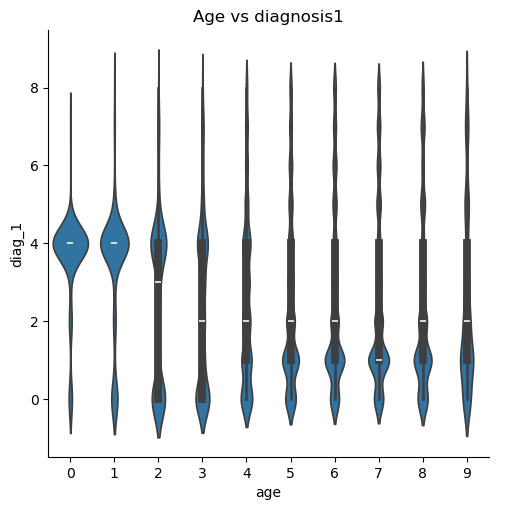

In [19]:
sns.catplot(x="age", y="diag_1",kind="violin", data=train_data);
plt.title('Age vs diagnosis1');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


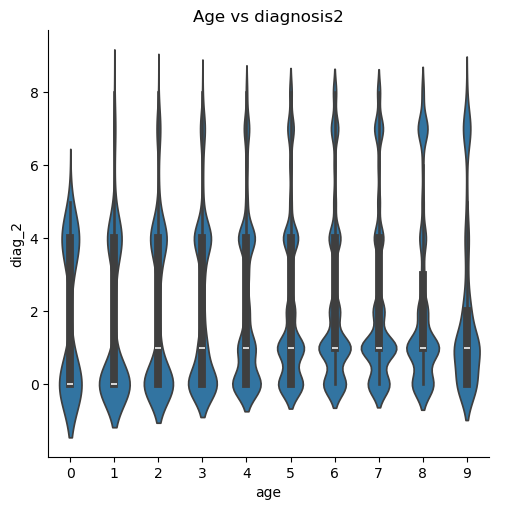

In [20]:
sns.catplot(x="age", y="diag_2",kind="violin", data=train_data);
plt.title('Age vs diagnosis2');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


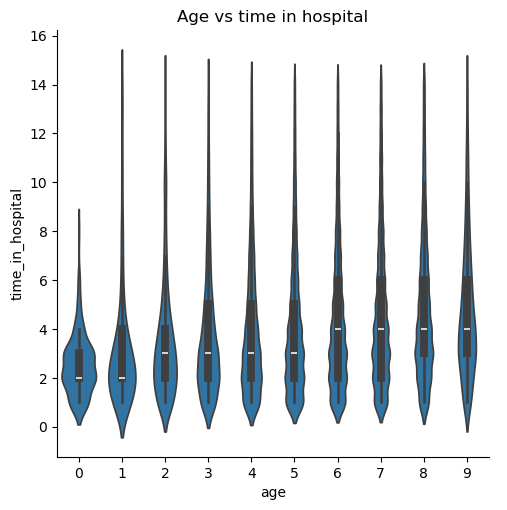

In [21]:
sns.catplot(x="age", y="time_in_hospital",kind="violin", data=train_data);
plt.title('Age vs time in hospital');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


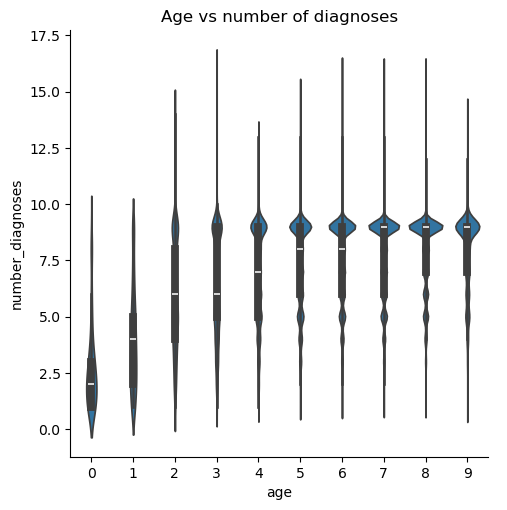

In [22]:
sns.catplot(x="age", y="number_diagnoses",kind="violin", data=train_data);
plt.title('Age vs number of diagnoses');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


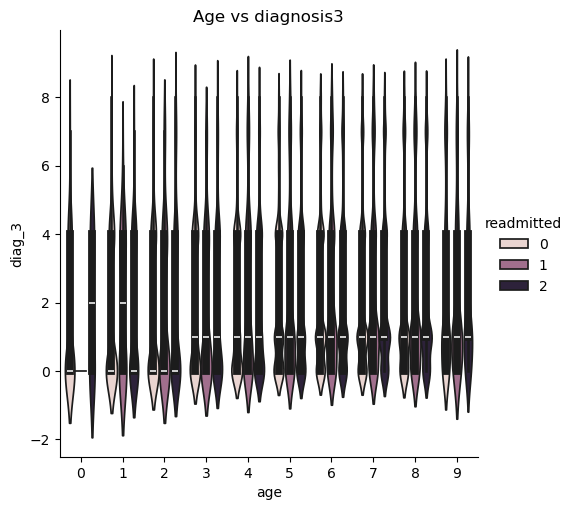

In [23]:
sns.catplot(x="age", y="diag_3",hue='readmitted',kind="violin", data=train_data);
plt.title('Age vs diagnosis3');

### Race VS diagnosis,admission_type_id & time in hopital

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


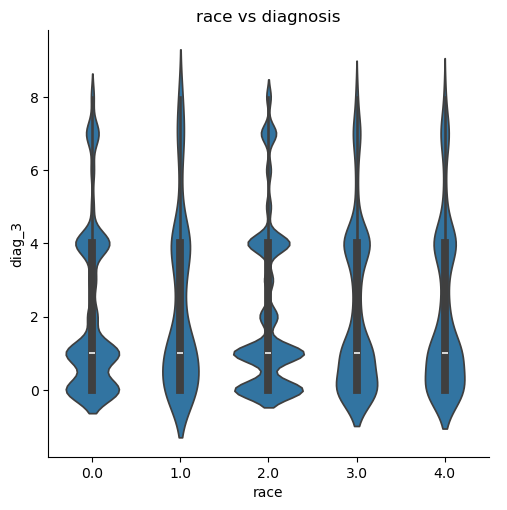

In [24]:
sns.catplot(x="race", y="diag_3",kind="violin",data = train_data)
plt.title('race vs diagnosis');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


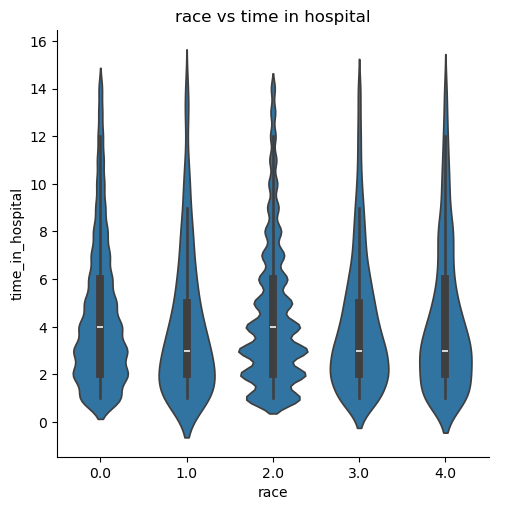

In [25]:
sns.catplot(x="race", y="time_in_hospital",kind="violin", data=train_data);
plt.title('race vs time in hospital');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


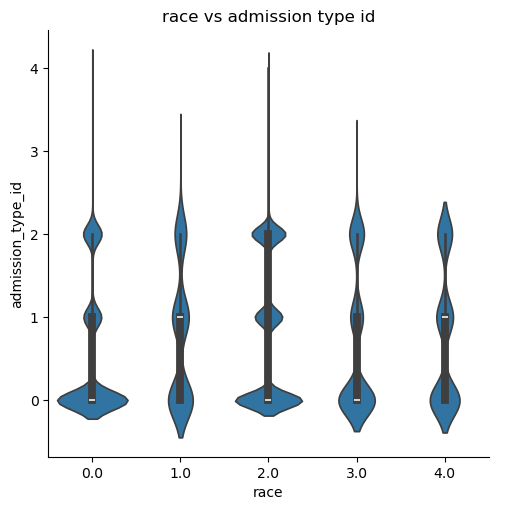

In [26]:
sns.catplot(x="race", y="admission_type_id",kind="violin", data=train_data);
plt.title('race vs admission type id');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


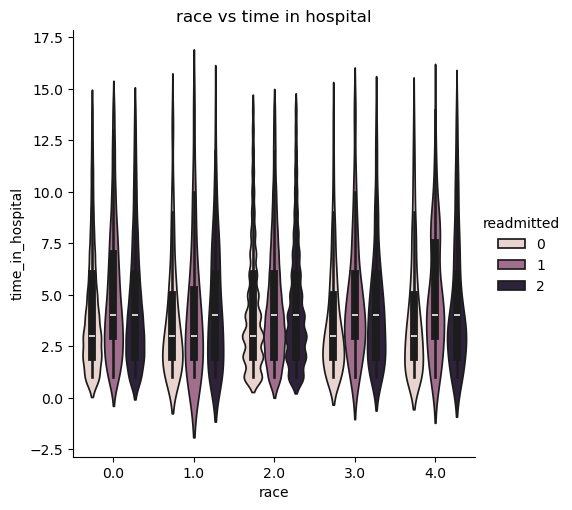

In [27]:
sns.catplot(x="race", y="time_in_hospital",hue='readmitted',kind="violin", data=train_data);
plt.title('race vs time in hospital');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


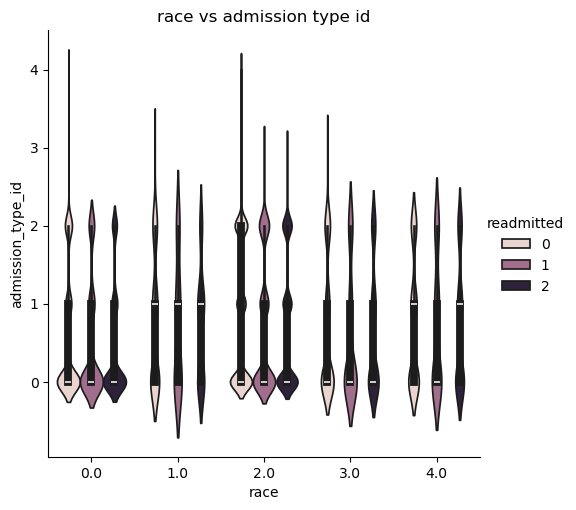

In [28]:
sns.catplot(x="race", y="admission_type_id",hue='readmitted',kind="violin", data=train_data);
plt.title('race vs admission type id');

### gender

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


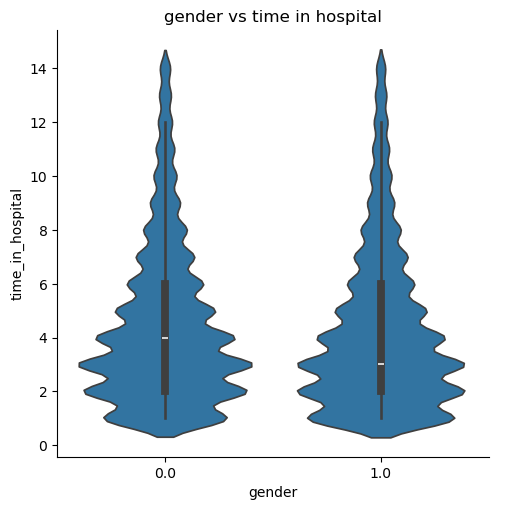

In [29]:
sns.catplot(x="gender", y="time_in_hospital",kind="violin", data=train_data);
plt.title('gender vs time in hospital');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


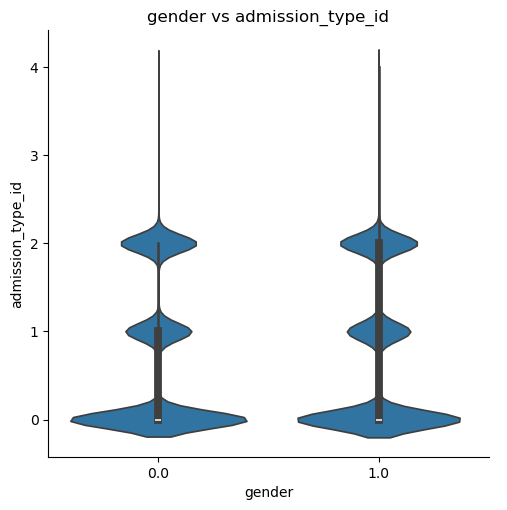

In [30]:
sns.catplot(x="gender", y="admission_type_id",kind="violin", data=train_data);
plt.title('gender vs admission_type_id');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


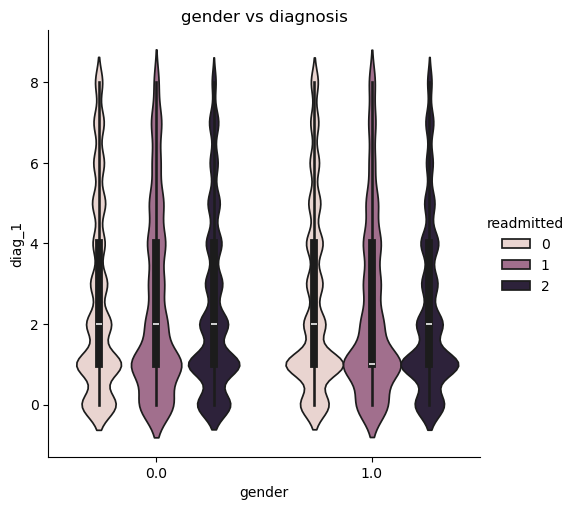

In [32]:
sns.catplot(x="gender", y="diag_1",hue='readmitted',kind="violin", data=train_data);
plt.title('gender vs diagnosis');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


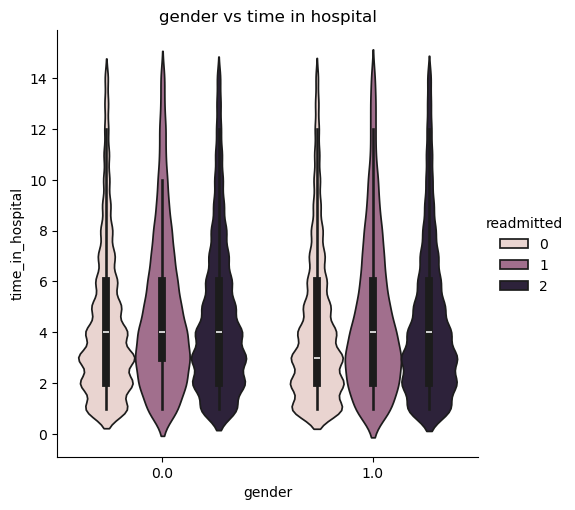

In [33]:
sns.catplot(x="gender", y="time_in_hospital",hue='readmitted',kind="violin", data=train_data);
plt.title('gender vs time in hospital');

### Admission type id

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


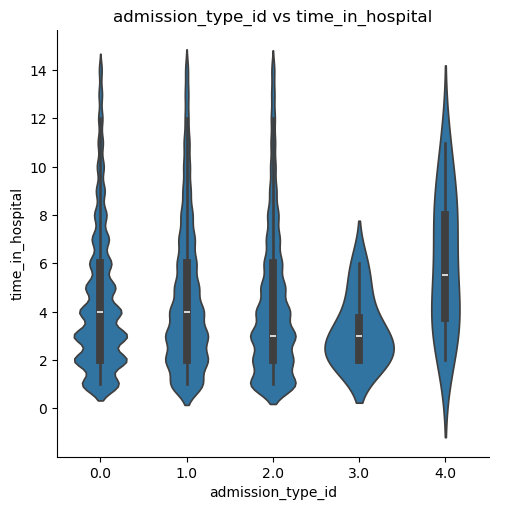

In [34]:
sns.catplot(x="admission_type_id", y="time_in_hospital",kind="violin", data=train_data);
plt.title('admission_type_id vs time_in_hospital');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


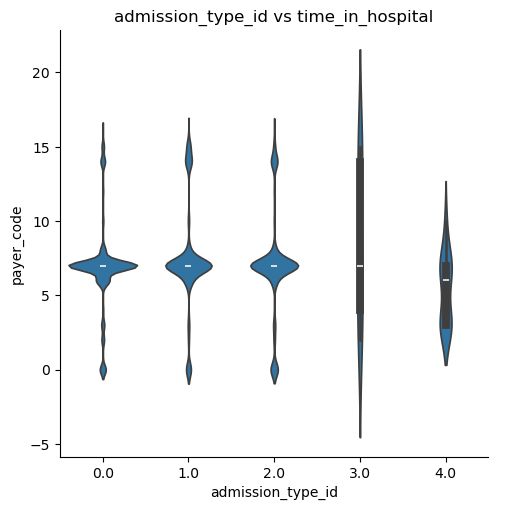

In [35]:
sns.catplot(x="admission_type_id", y="payer_code",kind="violin", data=train_data);
plt.title('admission_type_id vs time_in_hospital');

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


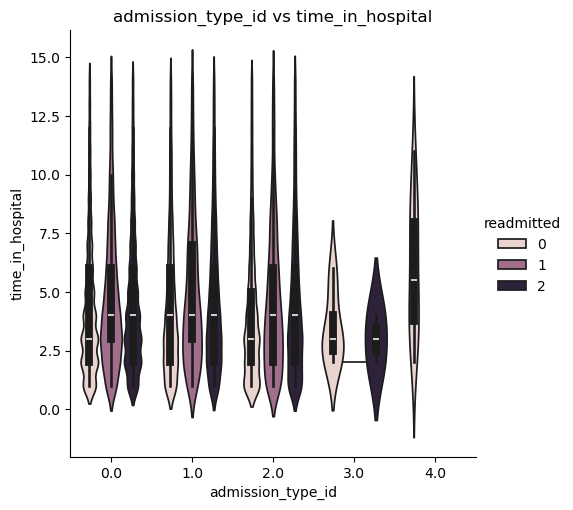

In [37]:
sns.catplot(x="admission_type_id", y="time_in_hospital",hue='readmitted',kind="violin", data=train_data);
plt.title('admission_type_id vs time_in_hospital');

### discharge_disposition_id

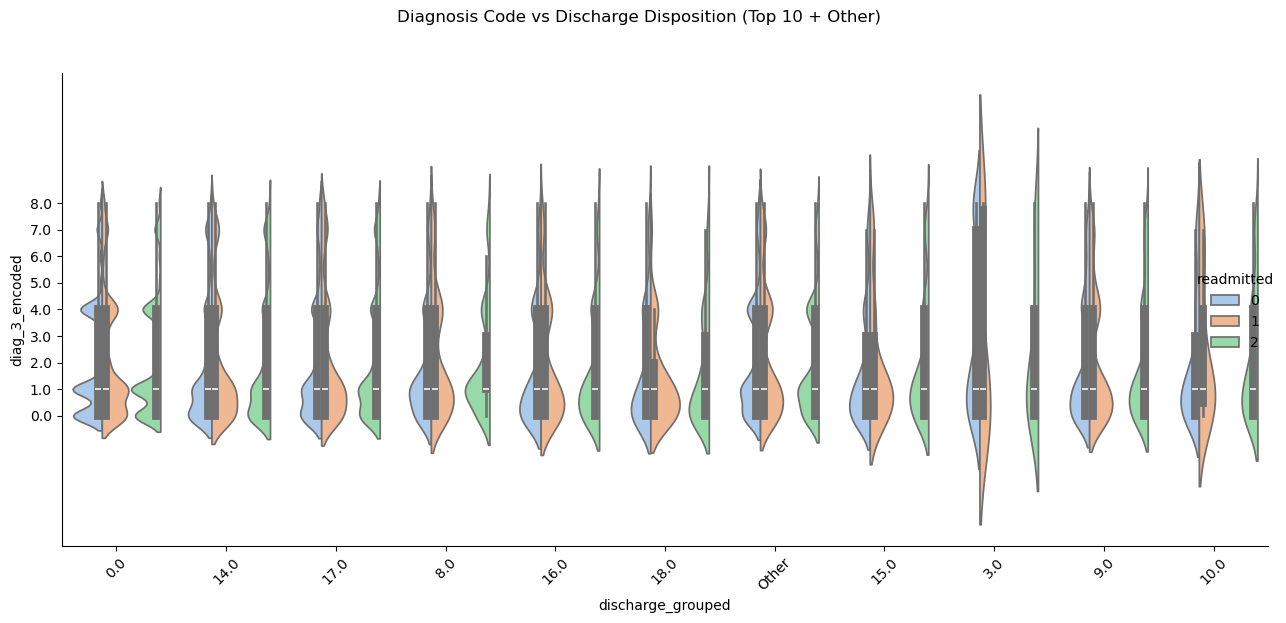

In [10]:
#sns.catplot(x="discharge_disposition_id", y="diag_3",hue='readmitted',kind="violin", data=train_data);
#plt.title('discharge_disposition_id vs diagnosis');

top10_ids = train_data['discharge_disposition_id'].value_counts().nlargest(10).index
train_data['discharge_grouped'] = train_data['discharge_disposition_id'].apply(
    lambda x: x if x in top10_ids else 'Other'
).astype(str)

# 将 diag_3 转换为字符串（避免被当成连续数值）
train_data['diag_3_str'] = train_data['diag_3'].astype(str)

# 为了绘图，临时转换 diag_3 为整数编码（用于 y 轴，但视觉用）
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_data['diag_3_encoded'] = le.fit_transform(train_data['diag_3_str'])

# 绘制小提琴图（仍为视觉展示）
g = sns.catplot(
    x="discharge_grouped",
    y="diag_3_encoded",
    hue="readmitted",
    kind="violin",
    data=train_data,
    height=6,
    aspect=2,
    split=True,
    palette="pastel"
)

# 将 y 轴转换为 diag_3 标签
tick_positions = sorted(train_data['diag_3_encoded'].unique())
tick_labels = le.inverse_transform(tick_positions)
g.ax.set_yticks(tick_positions)
g.ax.set_yticklabels(tick_labels)

# 图美化
g.set_xticklabels(rotation=45)
g.fig.suptitle("Diagnosis Code vs Discharge Disposition (Top 10 + Other)", y=1.03)
plt.tight_layout()
plt.show()



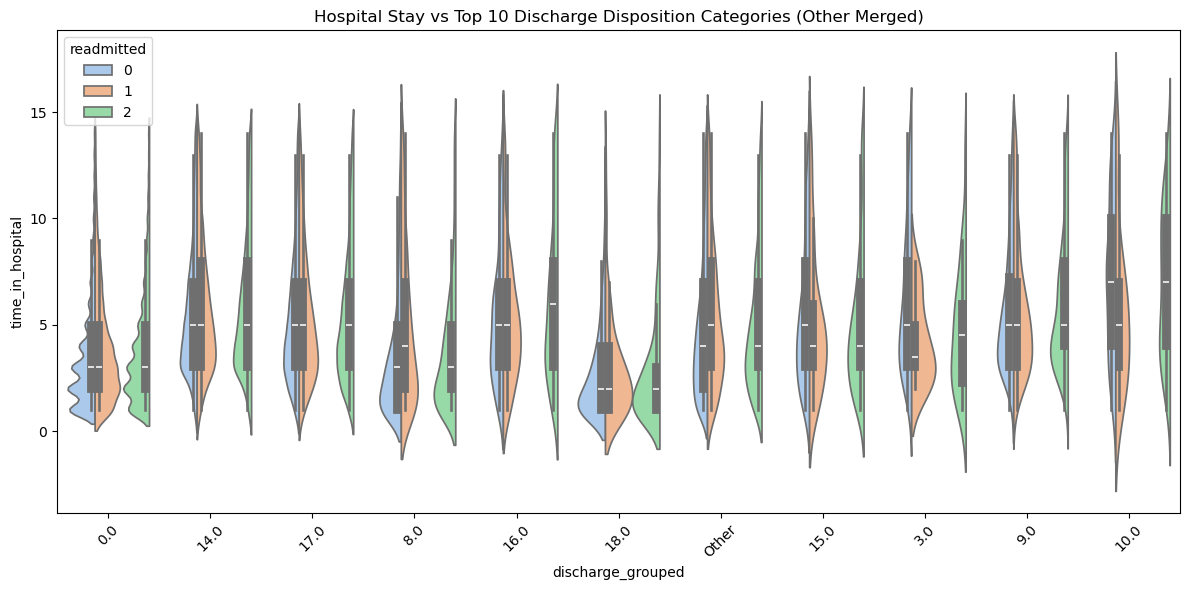

In [ ]:
#sns.catplot(x="discharge_disposition_id", y="time_in_hospital",hue='readmitted',kind="violin", data=train_data);
#plt.title('admission_type_id vs time_in_hospital');

# 取前 10 个出现频率最高的 discharge_disposition_id
top_10_ids = train_data['discharge_disposition_id'].value_counts().nlargest(10).index

# 创建一个新的列，保留 top 10，其余设为 "Other"
train_data['discharge_grouped'] = train_data['discharge_disposition_id'].apply(
    lambda x: x if x in top_10_ids else 'Other'
)

train_data['discharge_grouped'] = train_data['discharge_grouped'].astype(str)

# 绘图
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="discharge_grouped",
    y="time_in_hospital",
    hue="readmitted",
    data=train_data,
    split=True,
    palette="pastel"
)

plt.title('Hospital Stay vs Top 10 Discharge Disposition Categories (Other Merged)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### correlation

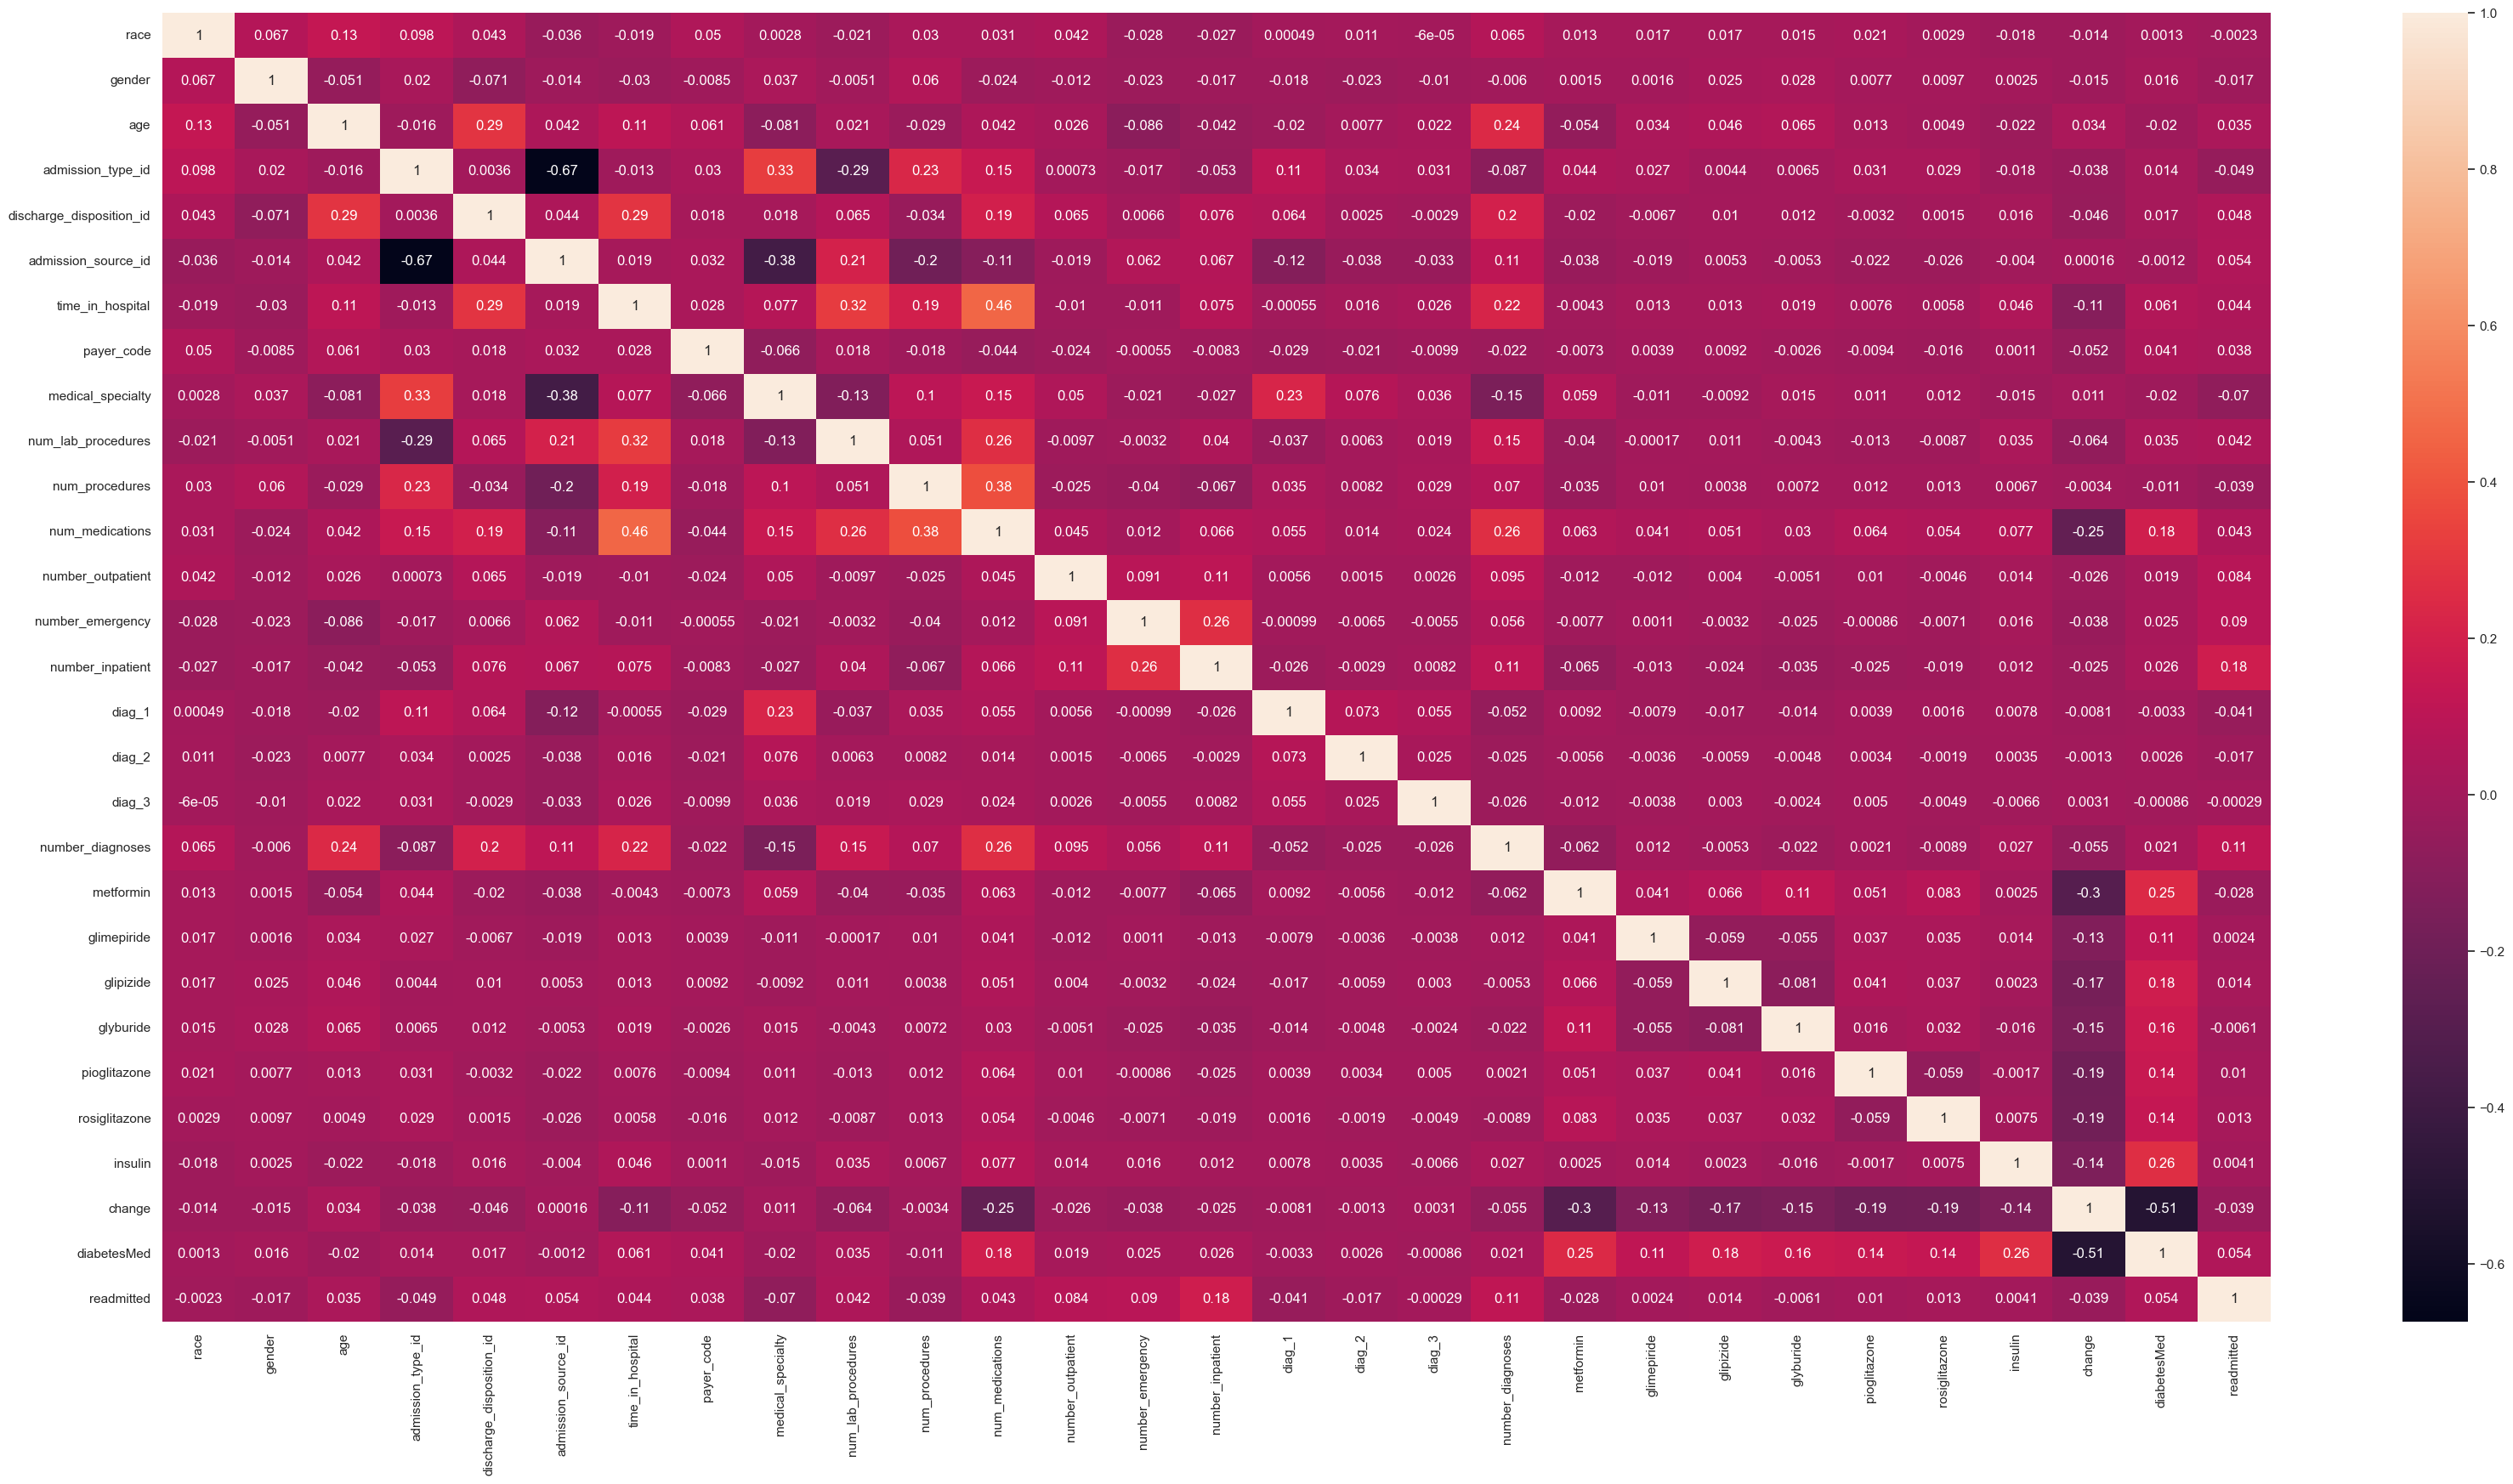

In [46]:
plt.figure(figsize=(40, 20))

data_corr = train_data.corr()
sns.heatmap(data_corr, 
            xticklabels = data_corr.columns.values,
            yticklabels = data_corr.columns.values,
            annot = True);

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = train_data[['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'metformin', 'glimepiride', 'glipizide',
       'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change',
       'diabetesMed', 'readmitted']]
vif = pd.DataFrame()
vif["variables"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [48]:
vif

,variables,VIF
0,race,4.994721
1,gender,1.896614
2,age,18.267544
3,admission_type_id,3.360083
4,discharge_disposition_id,1.915252
5,admission_source_id,6.116486
6,time_in_hospital,4.633617
7,payer_code,6.096786
8,medical_specialty,4.156510
9,num_lab_procedures,7.244869


# Methodology Overview
Code for the equivalent section in your report, together with in-line documentation of
that code.

# Model Training & Validation
Code for the equivalent section in your report, together with in-line documentation of
that code.

In [1]:
! bash train.sh

=== 开始GPU训练 ===
环境变量设置完成:
LD_LIBRARY_PATH: /opt/miniconda3/envs/309/lib:
CUDA_HOME: /opt/miniconda3/envs/309
CUDA_ROOT: /opt/miniconda3/envs/309
使用GPU设备: 4,5,7
检查GPU状态...
train.sh: line 21: nvidia-smi: command not found
=== 开始训练 ===
train.sh
#!/bin/bash

echo "=== 开始GPU训练 ==="

# 设置GPU环境变量
export LD_LIBRARY_PATH=$CONDA_PREFIX/lib:$LD_LIBRARY_PATH
export CUDA_HOME=$CONDA_PREFIX
export CUDA_ROOT=$CONDA_PREFIX

echo "环境变量设置完成:"
echo "LD_LIBRARY_PATH: $LD_LIBRARY_PATH"
echo "CUDA_HOME: $CUDA_HOME"
echo "CUDA_ROOT: $CUDA_ROOT"

# 设置可见的GPU设备（选择相对空闲的GPU）
export CUDA_VISIBLE_DEVICES=4,5,7
echo "使用GPU设备: $CUDA_VISIBLE_DEVICES"

# 检查GPU状态
echo "检查GPU状态..."
nvidia-smi --query-gpu=index,name,memory.used,memory.total,utilization.gpu --format=csv,noheader,nounits | grep -E "(3|4|5|6)"

echo "=== 开始训练 ==="

model="ResNet"
# mode="selected"
mode="LR"
# mode="one_hot"
k=all
feature_selector=None
resnet_epochs=1000
isoversample=true
resnet_batch_size=128
resnet_gpu_batch_size=128 # 更新为最佳批次大小
eval=False


# Results
Code for the equivalent section in your report, together with in-line documentation of that code

In [ ]:
from src.data_fit import DataFit
from argparse import Namespace
args = Namespace(
    mode='network_data',           # 数据集模式: 'normal', 'selected', 'network_data', '2class'
    isoversample=True,            # 是否使用过采样
    exp_name='report',      # 实验名称
    k='all',                       # 特征选择数量: 'all' 或整数
    model='ResNet',                # 模型名称: 'all', 'ResNet', 'RandomForest', 'GradientBoosting', 'LogisticRegression'
    feature_selector="None",         # 特征选择方法: 'chi2', 'f_classif', None
    resnet_batch_size=128,     # ResNet批次大小
    resnet_gpu_batch_size=128,     # ResNet GPU批次大小
    resnet_epochs=1000,             # ResNet训练轮数
    cover_old_result=True,         # 是否覆盖旧的实验结果
    eval=True
)
data_fit = DataFit(args=args)
data_fit.run_complete_pipeline()

# Final Predictions on Test Set
Code for the equivalent section in your report, together with in-line documentation of
that code.